* 抓取美妝保健類，留下時間/商品/銷售額/銷售量
* 分類美妝類或不是美妝類（保健類），只留下美妝類
* 清理商品名稱 （e.g. 第x標）
* 將商品名中之國家拉出來成一欄位
* 將商品名中之品牌拉出來成一欄位
* 將有品牌名但無國家者依品牌填入國家欄位
* 清除沒有品牌亦沒有國家之商品



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import Series, DataFrame

##讀取資料

In [ ]:
# 連接到Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 指定檔案所在資料夾
folder_path = '/content/drive/MyDrive/期末專案資料-20231106/'

# 初始化一個空的DataFrame
result_df = pd.DataFrame()

# 使用循環讀取多個檔案 (1~12月)
for i in range(1, 13):
    # 使用 f-string 確保數字部分有兩位數(01,02...)
    file_number = str(i).zfill(2)
    file_name = f'商品資料-2022_{file_number}.xlsx'
    file_path = folder_path + file_name

    print(f"Reading file: {file_path}")
    # 使用pandas讀取檔案
    df = pd.read_excel(file_path)

    # 選取需要的欄位
    selected_columns = ['time', 'category', 'name', 'total_quantity', 'total_amount']
    df_selected = df[selected_columns]

    # 條件篩選 category 為 '美妝保健'
    df_selected = df_selected[df_selected['category'].apply(lambda x: '美妝保健' in x)]
    #df_selected = df_selected[df_selected['category'] == '\[\'美妝保健\'\]'] <-這行不知道哪裡錯ㄌ

    # 在這裡對資料進行操作，例如合併或處理

    # 將處理後的資料附加到結果DataFrame中
    result_df = pd.concat([result_df, df_selected], ignore_index=True)

Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_01.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_02.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_03.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_04.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_05.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_06.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_07.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_08.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_09.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_10.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_11.xlsx
Reading file: /content/drive/MyDrive/期末專案資料-20231106/商品資料-2022_12.xlsx


In [ ]:
result_df

,time,category,name,total_quantity,total_amount
0,2022-01-09 13,['美妝保健'],韓國天然護手霜,1,0
1,2022-01-03 06,['美妝保健'],膠囊式護髮油50粒1罐,6,960
2,2022-01-04 06,['美妝保健'],妞第 007 標 (12/24)神奇護髮素+1片面膜,4,1596
3,2022-01-04 10,['美妝保健'],H第 029 標 (12/26)蔓越莓膠原蛋白,1,299
4,2021-12-31 16,['美妝保健'],跨年禮物 韓國最新面膜一盒 隨機,94,0
...,...,...,...,...,...
352111,2022-12-31 15,['美妝保健'],第 095 標 (12/31)Haimeier海玫爾-MACA-IN無限力量膠囊(6盒一組),12,36960
352112,2022-12-31 15,['美妝保健'],第056標(12/31)草本艾草足貼30入一盒50元,63,3150
352113,2022-12-31 15,['美妝保健'],第 001 標 (12/31)男生素顏霜*1,1,65
352114,2022-12-31 15,['美妝保健'],12/31(預)1221-醫美級洗面乳(30包),6,1194


##資料前處理


In [ ]:
#儘量留下美妝類，尤其臉部產品（去除：任何吃的、洗髮、沐浴、護髮、乾洗手、護手、其他有看到的奇奇怪怪的）增加後續處理效率
delete_check = pd.DataFrame()

filter_value = '脫毛|臍貼|防蚊|鏡子|馬桶|黑色風暴|必凹|深層水|每朝健康|T霸|近江|除螨|暖宮|掏耳|和牛|茶包|清體素|丸|香皂|錶|酵素|果凍|蘿蔔糕|汁|無糖|號商品|食品|足部|足貼|保險套|私密|長褲|褲|暖暖包|素食|龜鹿|苦瓜胜肽|洗手|碇|衛生棉|白腎豆|AB鑽|雙酵奇蹟|髮膜|葉黃素|奶昔|新普利|飲|泡澡球|益生菌|沐浴|雞湯|蠟燭|魚油|薑黃維生素|托盤|帽T|咖啡|相機包|身體'
filter = ~result_df['name'].str.contains(filter_value)
check = result_df['name'].str.contains(filter_value)
delete_check = result_df[check]
result_df = result_df[filter]

filter_value1 = 'Nubio|潔牙粉|中獎|派康斯|王老吉|挺立|漱口水|土魠|胭脂蝦|駝鳥|髪|髮|鮢過|手工皂|鱈魚|鮭魚|美甲|名屋|葛根|口罩|鍊|梳|蚓激酶|健體素|溫槍|蔓越莓|果膠|指甲|護手|牙膏|暢快人生|貼布|肽粉|裙|襪|鴕鳥|氣泡水|雞精|酥|消毒噴霧|膠原蛋白飲|內褲|護髮|栗子|軟糖|膠囊|錠|金牌|洗髮|頭皮|膠原蛋白粉|眼罩|晶凍|益菌|印加果油|黑喉|紅盤|藍星斑|牛樟芝|櫻花蝦|帽'
filter1 = ~result_df['name'].str.contains(filter_value1)
check1 = result_df['name'].str.contains(filter_value1)
delete_check = pd.concat([delete_check , result_df[check1]],axis=0)
result_df = result_df[filter1]

filter_value2 = 'LEMONA|BOTO|美壽壽|亞希朵|VM女神水|VM女神可可|儲值紅利點數|納豆|酒精噴物袋|口含|麵|短夾|長夾|刀|蜂蜜冰|刮痧|癬|肉鬆|鬆餅|香鬆|素T|脂流茶|台糖美漾纖|短T|吊墜|卵磷脂|黑毛|鮪魚|固力伸|肛|金線|福箱|送現金|BB夾|B群|腳|檸檬荷葉茶|甲片|享舒視|棉踢|除蟑|黑棗|寶茶|何首烏|龍根菌|斤|美體茶|酸痛|鈣|果醋|梨山茶|腰椎貼|餅乾|老虎T|亞鐵|蹦|速纖|挖耳|除蹣|冷敷貼|全素|寵物|鍋|鞋'
filter2 = ~result_df['name'].str.contains(filter_value2)
check2 = result_df['name'].str.contains(filter_value2)
delete_check = pd.concat([delete_check , result_df[check2]],axis=0)
result_df = result_df[filter2]

#字數小於四的也刪掉(國家or品牌加上商品名至少有四個字才能完整表達)
filter_condition = result_df['name'].str.len() >= 4
check3 = ~(result_df['name'].str.len() >= 4)
delete_check = pd.concat([delete_check , result_df[check3]],axis=0)
result_df = result_df[filter_condition]

#屬於贈送的刪掉（有銷售數量、但金額為零）
filter_condition2 = ~((result_df['total_quantity'] > 0) & (result_df['total_amount'] == 0))
check4 = ((result_df['total_quantity'] > 0) & (result_df['total_amount'] == 0))
delete_check = pd.concat([delete_check , result_df[check4]],axis=0)
result_df = result_df[filter_condition2]
result_df

,time,category,name,total_quantity,total_amount
8,2021-12-31 16,['美妝保健'],第 102 標 (12/31)亮顏霜*1,8,800
10,2021-12-31 16,['美妝保健'],第 104 標 (12/31)日本夜面霜*1,1,150
12,2021-12-31 16,['美妝保健'],第 110 標 (12/31)亮顏霜*1,1,100
13,2021-12-31 16,['美妝保健'],第 048 標 (12/31)24K黃金安瓶面膜(一盒10入),9,1692
15,2021-12-31 17,['美妝保健'],第 049 標 (12/31)EX亮妍白C(一盒30粒),8,2072
...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],第 013 標 (12/31)2022年度德國水解膠原蛋白-買4盒送3盒,8,47680
352109,2022-12-31 15,['美妝保健'],第 624 標 (12/31)珍優蛋白素1罐900 每人限4,58,52200
352113,2022-12-31 15,['美妝保健'],第 001 標 (12/31)男生素顏霜*1,1,65
352114,2022-12-31 15,['美妝保健'],12/31(預)1221-醫美級洗面乳(30包),6,1194


In [ ]:
#檢查清除掉的部分
delete_check

,time,category,name,total_quantity,total_amount
6,2021-12-31 16,['美妝保健'],第 043 標 (12/31)龜鹿鴕鳥精(一盒30粒),28,7840
7,2021-12-31 16,['美妝保健'],第 044 標 (12/31)金盞花葉黃素凍露(一盒10入),17,2873
9,2021-12-31 16,['美妝保健'],第 045 標 (12/31)EX苦瓜胜肽 木鱉果(一盒30粒),14,4186
17,2021-12-31 23,['美妝保健'],第 005 標 (1/1)醒膚沐浴乳+洗髮乳,1,250
18,2021-12-31 23,['美妝保健'],第 006 標 (1/1)凱蒂娜咖啡魅體沐浴乳-福利標,5,400
...,...,...,...,...,...
351990,2022-12-31 14,['美妝保健'],20221231晚場小禮物(150位)-品牌后隨機小樣(一片),150,0
351992,2022-12-31 14,['美妝保健'],20221231晚場小禮物-隨機款超美飾品(15位),15,0
352002,2022-12-31 14,['美妝保健'],(12/31) 分享禮-龍牌,1,0
352013,2022-12-31 14,['美妝保健'],第 270 標 (12/31)蘭蔻 卸妝乳(兩罐),1,0


####清除多餘文字

In [ ]:
import re

def clean_product_name(product_name):

    # 清除固定開頭格式
    product_name = re.sub(r'第.*?標', '', product_name)
    product_name = re.sub(r'\(\d{1,2}\/\d{1,2}\){1,2}', '', product_name)
    product_name = re.sub(r'\*\d{1,2}|\*\?', '', product_name)
    product_name = re.sub(r'888|\(闆\)888|公主|\(闆\)公主|荺蕎|大師兄|王三郎|妞|阿彤|月阿彤|畢哥|秀炮|柒CHI|慧|叫賣哥|叫賣', '',product_name)
    product_name = re.sub(r'\d{4} \w\d{2}-|\d{4}-\w\d{2}-', '', product_name)

    # 清除部分固定結尾
    product_name = re.sub(r'-\w+價$|-\w+標$|-\w+看$', '', product_name)

    #清除效期
    product_name = re.sub(r'效期到?|期限|期效|效:','',product_name)
    product_name = re.sub(r'\(\d+\/\d+\)|\(\d+\.\d+\)|\(:?\d+\.\d+\.\d+\)|\(:?\d+\/\d+\/\d+\)','',product_name)

    # 清除部分固定詞
    product_name = re.sub(r'預購款-|許願預購|許願|直播|居家預購|客戶指定--?|商城加購-|商城', '', product_name)
    product_name = re.sub(r'\d{1,2}\/\d{1,2} \w\d{2}|\d{4}_+\d{2}|\d{2} \(\d{1,2}\/\d{1,2}\)', '', product_name)
    product_name = re.sub(r'S\.L\s?', '', product_name)
    product_name = re.sub(r'P\d{4}|[A-Z]\(預購\)|G\d{2,4}-?\d?|I\d{2,3}|F\d{2,3}|[AB]\d{3}\(\d{4}\)', '', product_name)
    product_name = re.sub(r'限\w+：', '', product_name)
    product_name = re.sub(r'\(超賣刪單\)', '', product_name)

    # 清除價格
    product_name = re.sub(r'\$\d+', '', product_name)
    product_name = re.sub(r'一\w\d+元', '', product_name)

    # 清除任選、~~~
    product_name = re.sub(r'~', '', product_name)
    product_name = re.sub(r'任選', '', product_name)

    #lab1
    product_name = re.sub(r'\d{4}年\d{1,2}月\d{1,2}日|\d{4}年\d{1,2}月\d{1,2}號','',product_name)
    product_name = re.sub(r'\d{4}\/\d月\W\d月|\d{4}\/\d{1,2}\/\d{1,2}','',product_name)
    product_name = re.sub(r'\d{3,7}年\d{1,2}月?製?造?後?|^\d{3,5}年?\/{1,2}\d{1,2}月?製?造?後?|\d{4}年製?造?後?','',product_name)

    return product_name

In [ ]:
def clean_product_name2(product_name):
  # 再清除固定開頭格式
  product_name = re.sub(r'[YXVSRPNMLKJHEDCBA]\d{2,3}:?-?|^R\d{4}\w|^C[KD]\d{3}|^[ACB] \d{3} 標|^BB\d{3}|^AA\d{3}','',product_name)
  product_name = re.sub(r'^\d{1,2}\.\w{2}\d{2}-','',product_name)
  product_name = re.sub(r'此標沒有會員價|此標沒有VIP|現金價|S\+|HIT預購|^[FECBD]\w*\s?=', '', product_name)
  product_name = re.sub(r'-', '', product_name)
  product_name = re.sub(r'^\d+月\d+\w{2,3}\d+標\(?.*\)?[A-Z]\d{2}|^\d+月\d+\w{2,3}\d+標|^\d+月\d+\w{2,3}\(?.*\)?[A-Z]\d{2}', '', product_name)
  product_name = re.sub(r'^\d+\w{2,3}\s?\d+標', '', product_name)
  product_name = re.sub(r'^\(.*\)','',product_name)
  product_name = re.sub(r'分享獎', '', product_name)
  product_name = re.sub(r'\d{4}\.\d{1,2}', '', product_name)
  product_name = re.sub(r'\d{1,2}\/\d{1,2}-?', '', product_name)
  product_name = re.sub(r'^\d{4}-\d{4}|^\d{6}|^\d{8}', '', product_name)
  product_name = re.sub(r'[fh]\d{2}','',product_name)
  product_name = re.sub(r'\d+\+1','',product_name)

  # 刪除特定字詞
  product_name = re.sub(r'T包','',product_name)
  product_name = re.sub(r'買\w送\w','',product_name)
  product_name = re.sub(r'結標','',product_name)
  product_name = re.sub(r'結單','',product_name)
  product_name = re.sub(r'晚場','',product_name)
  product_name = re.sub(r'百貨區\d{3}','',product_name)
  product_name = re.sub(r'後台看價錢','',product_name)
  product_name = re.sub(r'公益標','',product_name)
  product_name = re.sub(r'二手','',product_name)
  product_name = re.sub(r'\d{1,3}\.{1,2}[WVCUTX]?','',product_name)

  # 刪除《》、()、『』之內的內容
  product_name = re.sub(r'^P\..+','',product_name)
  product_name = re.sub(r'\([^()]*\)|\（[^()]*\)|\（[^()]*\）|\([^()]*\）', '', product_name)
  product_name = re.sub(r'\".*\" ', '', product_name)
  product_name = re.sub(r'【週二限定】|【.*針管.*】|【.*商品.*】|【官方社團】|【女王回饋】', '', product_name)
  product_name = re.sub(r'【', '', product_name)
  product_name = re.sub(r'】', '', product_name)
  product_name = re.sub(r'^「.*」', '', product_name)
  product_name = re.sub(r'「', '', product_name)
  product_name = re.sub(r'」', '', product_name)
  product_name = re.sub(r'\（.*', '', product_name)
  product_name = re.sub(r'^\(', '', product_name)
  product_name = re.sub(r'^\)', '', product_name)
  product_name = re.sub(r'\(.*', '', product_name)
  product_name = re.sub(r'\).*', '', product_name)
  product_name = re.sub(r'，.*', '', product_name)
  product_name = re.sub(r'《下單.+》?', '', product_name)
  product_name = re.sub(r'\/', '', product_name)

  # 刪除特殊符號&單位
  product_name = re.sub(r'[！*?!-$=~：★@"《》]', '',product_name)

  # 移除多餘的空格
  product_name = ' '.join(product_name.split())

  return product_name

In [ ]:
#執行
result_df['name'] = result_df['name'].map(clean_product_name)
#result_df['cleaned_name'] = result_df['name'].apply(clean_product_name)

result_df['name'].replace(' ', np.nan, inplace=True)
result_df = result_df.dropna(subset=['name'])

In [ ]:
#執行二次清除
result_df['name'] = result_df['name'].map(clean_product_name2)
#result_df['cleaned_name'] = result_df['name'].apply(clean_product_name2)

#長度小於4無法同時包含國家及品名 故刪除
filter3 = ~result_df['name'].apply(lambda x: len(str(x)) < 4)
result_df = result_df[filter3]
#英文部分統一大寫
result_df['name'] = result_df['name'].str.upper()

<ipython-input-10-6c2ebfe8f887>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['name'] = result_df['name'].map(clean_product_name2)


In [ ]:
result_df

,time,category,name,total_quantity,total_amount
10,2021-12-31 16,['美妝保健'],日本夜面霜,1,150
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556
...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],度德國水解膠原蛋白買4盒送3盒,8,47680
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194


## CKIP斷詞
協助找出品牌名稱
##### (已經整理出品牌跟國家了可以不用再跑)

In [ ]:
!pip install -U ckiptagger[tf,gdown]
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER

# data_utils.download_data_url("./") # iis-ckip
data_utils.download_data_gdown("./") # gdrive-ckip

ws = WS("./data")
pos = POS("./data")
ner = NER("./data")

In [ ]:
import random
goodsname = result_df['name'].tolist()
#隨機挑出5000比做斷詞
random_sampled_list = random.sample(goodsname, 5000)
word_sentence_list = ws(random_sampled_list)
#pos_sentence_list = pos(word_sentence_list)
#entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

In [ ]:
entitylist=[]
for i, sentence in enumerate(goodsname):

  for j in range(len(word_sentence_list[i])):
    entities = word_sentence_list[i][j]
    entitylist.append(entities)
from collections import Counter
c = Counter(entitylist)
frequency = c.most_common()
#挑選出頻繁出現的詞語
for element, count in frequency:
  if count >= 20 & len(element) > 1 :
    print(f"{element}: {count} 次")

## CKIP之結果

雅詩蘭黛: 944 次
WHOO: 754 次
 100: 633 次
WHOO : 327 次
DIOR: 306 次
 WHOO: 269 次
CM 0: 247 次
YSL : 236 次
1000: 207 次
 120: 194 次
COACH: 186 次
DIOR : 180 次
GUCCI : 172 次
高麗雅娜: 168 次
GUCCI: 142 次
瑪可安迪: 133 次
 EDP : 131 次
 150: 125 次
潘海利根: 124 次
LANCOME: 119 次
 200: 115 次
OHUI: 109 次
NARCISO: 106 次
AHC : 105 次
 500: 101 次
HERMES : 96 次
2025: 96 次
1125: 93 次
 HITAM: 92 次
1111: 92 次
2022: 90 次
CHANEL : 89 次
雅詩蘭黛 : 87 次
CHANEL: 85 次
三宅一生: 80 次
NARS: 79 次
4711: 79 次
EAORON: 77 次
穀胱甘肽: 77 次
CHLOE: 76 次
 OHUI: 73 次
雅詩蘭黛特潤: 72 次
NARS : 69 次
超導石墨烯: 68 次
SABON : 67 次
ESTEE LAUDER: 65 次
COCO: 65 次
GIORGIO ARMANI : 63 次
ESTEE LAUDER : 61 次
 AHC : 61 次
JOAJOTA: 60 次
1118: 60 次
 HERA: 60 次
 300: 59 次
1108: 58 次
ML : : 56 次
PENHALIGON'S : 56 次
 PUTIH: 56 次
PUREMER: 56 次
BOBBI BROWN : 55 次
 250: 55 次
 SUM: 55 次
SABON: 54 次
透明質酸: 54 次
3CE : 53 次
SUM37: 52 次
HERMES: 51 次
雅斯蘭黛: 51 次
MAC : 51 次
拉絲頸霜: 51 次
COREANA: 50 次
G CELL FACTORY: 50 次
丹華炫美肌: 49 次
蠶絲蛋白: 48 次
CHLOE : 48 次
LA MER : 48 次
ML 1: 48 次
COACH : 45 次
KIEHL'S: 45 次
KARL LAGERFELD : 45 次
MYNI : 45 次
提拉安瓶: 45 次
 180: 44 次
保養品廠: 44 次
VT PRO: 44 次
黃金達摩: 44 次
LOEWE : 43 次
 EDT : 43 次
維多利亞: 43 次
三合一線: 43 次
BRE : 43 次
 🔹100: 43 次
怡麗絲爾: 42 次
PRO+: 42 次
KIEHLS : 42 次
COSNORI: 41 次
KAHI: 41 次
 125: 41 次
1112: 40 次
CNP RX : 40 次
UNNY: 39 次
ML +: 39 次
肉毒桿菌: 38 次
100%: 38 次
1110: 38 次
G PREMIUM RX: 38 次
1200: 37 次
 WHOO : 37 次
LANEIGE: 36 次
LALIQUE: 36 次
WRF : 36 次
LANVIN : 36 次
 2025: 36 次
享氣津生: 36 次
1016: 36 次
DAWON: 36 次
袪班面霜: 36 次
藍銅胜肽: 35 次
1014: 35 次
HERA: 35 次
TOUS: 35 次
MEDI PEEL 縮氨酸: 35 次
ANJO : 34 次
伊麗莎白雅頓: 34 次
SU:M: 34 次
BRE EX: 34 次
NATURE DREAM : 34 次
EAORON : 33 次
PENHALIGON'S: 33 次
顏皙美姬: 33 次
KIEHLS: 32 次
 1000: 32 次
LANVIN: 32 次
KLAVUU : 32 次
遠紅外線: 32 次
1102: 32 次
LGWHOO : 32 次
2024: 31 次
JAGUAR: 31 次
JMELLA: 31 次
 9CM 0: 31 次
葡萄糖胺: 30 次
XIXI: 30 次
SKII : 30 次
1500: 30 次
1201: 30 次
NOVO: 29 次
1800: 29 次
 YSL: 29 次
SU:M37: 29 次
IPSA: 29 次
 8CM 0: 29 次
BO.KIN: 29 次
ORIKS: 28 次
LADYKIN: 28 次
傳世生藥: 28 次
1021: 27 次
 AHC: 27 次
ML +2: 27 次
🐯虎頭蜂: 27 次
ISLEAF: 27 次
 🔹50: 27 次
KIN : 27 次
VT CICA: 27 次
瑪瑙花羅漢: 27 次
第五大道: 27 次
ANNASUI: 27 次
MEIYO : 27 次
九豐盈積: 27 次
1109: 27 次
奢華絲絨: 26 次
3500: 26 次
ML 2: 26 次
1114: 26 次
血烏魚子片: 26 次
CNP : 26 次
1121: 26 次
酒精香精: 26 次
1203: 26 次
蒂齊納泰倫斯: 25 次
KLAVUU: 25 次
ZERO: 25 次
ARMANI: 25 次
PRRETI : 25 次
KOSE: 25 次
TOUS : 25 次
1103: 25 次
ESPOIR : 25 次
DERMA MAISON : 25 次
6000: 25 次
SU:M : 24 次
后拱辰享: 24 次
IPSA : 24 次
㮀HAN｜: 24 次
 910: 24 次
BRE 18X: 24 次
MMPL : 24 次
1019: 24 次
6900: 24 次
PMPM: 23 次
GIORGIO ARMANI: 23 次
THE MERCHANT OF VENICE : 23 次
海克拉斯: 23 次
KAFEN: 23 次
一氧化氮精氨酸: 23 次
ORIGINS: 23 次
1280: 23 次
保養品組: 23 次
ML 價: 23 次
1023: 23 次
斑洗面乳: 23 次
 DR.: 22 次
 YSL : 22 次
VELLA: 22 次
晚安凍膜: 22 次
1208: 22 次
LA MER: 22 次
ML 3: 22 次
ACQUA DI PARMA : 22 次
OHUI : 22 次
 1011: 22 次
1212: 22 次
1218: 22 次
INERSENTIAL : 22 次
1104: 22 次
G RX SCM EXPERT: 22 次
 V FAU : 21 次
JBLIN: 21 次
美蒂菲 : 21 次
GODDESS IDUN: 21 次
SISLEY : 21 次
雅詩蘭黛粉: 21 次
1020: 21 次
EDP : 21 次
 5CM 0: 21 次
AHC B5: 21 次
ML+2: 21 次
1126: 21 次
1210: 21 次
MDOC: 20 次
PRRETI: 20 次
 24K: 20 次
HEIMISH: 20 次
SKII: 20 次
KENZO: 20 次
NARCISO FOR HER: 20 次
1008: 20 次
大禮盒組: 20 次

## 國家

In [ ]:
# ['🇰🇷','韓國製','韓國製造','日本製','台灣製','台灣製造','法國製','澳製',清邁]
countries = ['韓國','日本','台灣','保加利亞','英國','德國','美國','泰國','法國','西班牙','澳洲','義大利','土耳其']

def process_country(product_name):
    if '🇰🇷' in product_name:
        return '韓國', product_name.replace('🇰🇷', '')
    elif '韓國製造' in product_name:
        return '韓國', product_name.replace('韓國製造', '')
    elif '韓國製' in product_name:
        return '韓國', product_name.replace('韓國製', '')
    elif '日本製造' in product_name:
        return '日本', product_name.replace('日本製造', '')
    elif '日本製' in product_name:
        return '日本', product_name.replace('日本製', '')
    elif '台灣製造' in product_name:
        return '台灣', product_name.replace('台灣製造', '')
    elif '台灣製' in product_name:
        return '台灣', product_name.replace('台灣製', '')
    elif '法國製' in product_name:
        return '法國', product_name.replace('法國製', '')
    elif '澳製' in product_name:
        return '澳洲', product_name.replace('澳製', '')
    elif '清邁' in product_name:
        return '泰國', product_name
    else:
      return '',product_name

def process_country2(row):
    # 檢查 '國家' 欄位是否為空
    if (row['country']==''):
        product_name = row['name']
        found_country = None
        for country in countries:
           if country in product_name:
              found_country = country
              break  # 找到一個就中斷迴圈

        if found_country:
          return found_country, product_name.replace(found_country, '')
        else:
          return '', product_name

    else:
        # 如果 '國家' 欄位已經有值，保持不變
        return row['country'], row['name']

In [ ]:
#建立國家欄位並填入、同時將商品名稱中的國家清除
result_df['country'], result_df['name'] = zip(*result_df['name'].apply(process_country))
result_df[['country', 'name']] = result_df.apply(process_country2, axis=1, result_type='expand')
result_df

,time,category,name,total_quantity,total_amount,country
10,2021-12-31 16,['美妝保健'],夜面霜,1,150,日本
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692,
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072,
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99,
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556,
...,...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],度水解膠原蛋白買4盒送3盒,8,47680,德國
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200,
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65,
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194,


## 品牌

In [ ]:
#CKIP找出的品牌並加以人工整理（資料中存在許多錯字 或有中英品牌名 但只提到其中一個語言）
brands = ['FREDERIC MALLE','馥馬爾','麗仁堂','魔立奇肌','魔力奇肌','高麗雅娜','高麗亞娜','高莉亞娜','高莉雅娜','COREANA','香奈兒','CHANEL','顏佳宜','YANJIAYI',
 '雪花秀','SULWHASOO','SULWHASOP','SULWASHOO','PONY EFFECT',
 'MEDIPEEL','美蒂菲','美帝菲','JOAJOTA','CHASKIN','CHA SKIN','AHC','A.H.C','3W CLINIC', '3WCLINIC','LADYKIN','JIGOTT',
 'ETUDE','ANJO','韓倫美羽','HUNMUI','雪肌精','雪思黎','SISLEY','希思黎',
 '伊莉莎白雅頓','伊麗莎白雅頓','雅頓','ELIZABETH ARDEN','ELIZABETH',
 '雅詩蘭黛','ESTEE LAUDER','雅斯蘭黛','ESTEE','鉑菲','DIOR','迪奧','FAU','HR赫蓮娜','赫蓮娜','賓士','資生堂','SHISEIDO','貝蘭妃',
 '詩夢絲','SAGAXIU','詩佳秀','蘿拉蜜思','蘿拉蜜絲','LAURA MERCIER','蘭蔻','LANCOME','LANCÔME',
 '蘭芝','LANEIGE','GIORGIO ARMANI','ARMANI','亞曼尼','藍寶堅尼','LAMBORGHINI','蒂芬妮', 'TIFFANY & CO.','TIFFANY & LOVE','TIFFANY&CO','TIFANNY',
 '蓓莉LA PRAIRIE','萬寶龍','MONTBLANC','萊蔻','菲蘇德美','莎曼莉','莎思曼蒂','YINBA','茵芭','范倫鐵若','VALENTINO','芊語蔻','艾肯',
 '艾尚肌','美博士', 'DR. MAY','維密','維多利亞的秘密','維多莉亞秘密','維多利亞秘密', '維多利亞','VICTORIAʼS SECRET','VICTORIA SECRET',
 '維妮香','XHEKPON','紀梵希','紀凡希','GIVENCHY','CHERESKIN','CHERESKIK','HERES','ZAVAVA','秀雅韓','生命之鑰','瑪莉安娜',
 '瑪可安迪','MACKANDY','MACK ANDY','理膚寶水','理膚','爾木萄','爾木桃','AMORTALS','熊野','澳韻詩','SINICARE',
 'EAORON','潘海利根','PENHALIGON’S', "PENHALIGON'S",'海洋拉娜', 'LA MER','海克拉斯','浪凡','JEANNE LANVIN','LANVIN',
 '活萌力','BOOTS','法顏蔻','FAYANKOU','法汀妮','貝膚黛瑪','BIODERMA','ATELIER COLOGNE','泊泉雅','伯泉雅','比芭美','每人美',
 'LASH TOC','歐頌','AUSONE','歐蕙','歐惠','OHUI','歐舒丹',"L'OCCITANE","L’OCCITANE",'歐姬兒','欣雅妝',
 '機爾根圖', '基爾根圖','植貝','植村秀','SHUUEMURA','SHU UEMURA','森田藥妝','森田藥粧','梵貞','格蒙','柏晶', 'BO.KIN',
 '東星製藥','東興製藥','東興','DONGSUNG','東星','DONG SUNG','未來美','NARIS','SENK','SENKA',
 '文斯卡穆托','文思卡穆托','VINCE CAMUTO','故事與她','故事與他','GUSHIYUTA','拉美拉','戈戈舞','愛馬仕','HERMÈS','HERMES',
 '愛迪達','ADIDAS','愛茉莉太平洋','愛茉莉AP','愛茉莉','AMOREPACIFIC','AMORE PACIFIC','悠色','悅詩風吟','INNISFREE',
 '怡麗絲爾','GLYSOLID','BALEA','彼得羅夫','形象美','帶槍茱麗葉','JULIETTE HAS A GUN','帕爾瑪之水','ACQUA DI PARMA',
 '巴黎元素','EVOLUDERM','寶格麗','BVLGARI','宮束','安娜蘇','安納蘇','ANNASUI','ANNA SUI','嬌蘭','GUERLAIN','妃詩兒','FACEE',
 '契爾氏',"KIEHL'S",'契爾式','契爾士','KIEHL`S','KIEHLS','KIEHL S','品木宣言','ORIGINS','吹牛老爹','SEAN JOHN','吟遊詩人','MONOTHEME',
 '台鹽生技','台鹽','台酒生技','台酒','台糖','三郎 FORTE','台塑FORTE','台塑 FORTE','台塑','三郎','卡爾','KARL LAGERFELD','KARL',
 '卡卡西', 'KAKAXI','VERSACE','凡賽斯','冰韻','云錦熙','YOUNCY','儷人凱RE:NK','RENK麗人凱','RE:NK麗人凱','RE:NK儷人凱',
 '傳世生藥','倩碧','CLINIQUE','伯瓊','寶詩龍','BOUCHERON','井尚美','JINSAMY','ISSEY MIYAKE','三宅一生','VPAC','薇茵','ESHUMI',
 'ZV','YZS','YZMY','櫻姿蜜語','YVES DE SISTELLE','YUANLI願麗','YSL','聖羅蘭','YAQINUO','TOM FORD','TOMFORD','TF',
 'NARS','XIXI','XIUSE羞瑟','XERJOFF',"WOMEN'SECRET",'MFK','MAISON FRANCIS KURKDJIAN',
 'VM女神','VDL','VASELINNE','VASELINE','VANEKAK','VAN CLEEF & ARPELS','VALMONT法而曼','UNNY VXDU','TVLV','TRUSSARDI','楚沙迪',
 'TOUS','TOO FACED','TOO COOL FOR SCHOOL','TOMMY','TIZIANA TERENZI','蒂齊納泰倫斯','THERA LADY',
 'THE MERCHANT OF VENICE 威尼斯商人','THE HOUSE OF OUD','TALE APPEAL','SU:M37','SU:M','SUM:37','SUM37','SU呼吸','SU:呼吸',
 'SUVARN','STRIVECTIN','SPA MASTER','SOSOLEE','SOME BY MI','SODA BEAUTY','SMASHBOX','SKII','SK2','SEXYLOOK',
 'SERGE LUTENS','蘆丹氏','SCARLETT','SALVATORE FERRAGAMO','SABON','ROJA','ROCHAS',"Q'HER植感",'Q HER','PUREMER',
 'PUREDERM','PRRETI','PRADA','PLUNA','PIPL','歐束菲','OSUFI','NOVO',
 'NARCISP','NARCISO RODRIGUEZ','NARCISO','MULDREAM','MOSCHINO','MOROCCANOIL','MOROCCAN OIL','MONTNATUR','MONT NATURE','MONT NATUR',
 '蜜詩黛兒','MIXDAIR','MIUMIU','MIU MIU','MISSONI','MILLER HARRIS','MICHAEL KORS','MAISON MARGIELA','MAC',
 'L’ARTISAN PARFUMEUR','阿蒂仙之香',"L'ARTISAN PARFUMEUR",'LOEWE','LIQUIDES IMAGINAIRES','LALIQUE','萊儷','LADYKIN',
 'LA RIVE','KOSE','KORLOFF','KAFEN','KF','KENZO','KATE SPADE','KATE SAPDE','JOMALONE','JO MALONE','JOHN VARVATOS',
 'JOAJOTA','JLO','珍妮佛羅培茲','JENNIFER LOPEZ','JIMMY CHOO','JIGOTT','JAGUAR','ISLEAF','IS LEAT','IPSA','HOJO',
 'HASPOEMI','韓詩蜜','GUICAMI','GUESS','GUCCI','GIK','FURLA','芙拉','FERRAGAMO','FASY SHOP','霏思小舖','EVOQUER',
 'ETUDE','ELIBEAUTY','ELI BEAUTY','ELIBAUTY','ELIZECOSMO','DR.沛思','DR.PIZ','沛思','DR.MAINZ','DR. PEPTI','DR. HSIEH','DIPTYQUE','D&G','CQRZEN',
 'COACH','CNP','CLE DE PEAU','肌膚之鑰','CHLOE','CHARLOTTE TILBURY','BURBERRY','BONAIFEI珀奈菲','BOBBI BROWN',
 'BIOTOC','BBW','麗珠蘭','INFINITE ALOE','ABERCROMBIE & FITCH','A&F','ACCA KAPPA',
 'AESOP','AIITOGETHER','AMOUAGE','ANGELKEY','ANGEL KEY','ARZTIN','ATELIER','LUDEYA','VT','赫拉','HERA',
 "CAB'S",'卡碧絲','ORMONDE JAYNE','碧歐斯','BIO','黎芙莎','香蒲麗','SHANGPREE','薇塔蜜','VITAME','瑪莎莉莉','瑪莉莎莎','滋卿愛','清銀露',
  '梵希茜','朴妝','MOLIYUEDING','魔力約定','MOMOIA','瑪莫雅','MDOC','LE LABO','LA CASA',"L'EGERE","蘭吉兒",'JENNY HOUSE','DUNHILL',
          'DAERA','CHERRY KO櫻桃蔻','BUNNY FRESH','邦妮兔','FERRARI','法拉利','DSQUARED2','茵芙莎']
special_brands =['WHOO 后','后WHOO','后 WHOO','WHOO後','WHOO后','WHOO']

In [ ]:
allbrands=brands+special_brands
#找出每個name裡面的品牌(有些是多個品牌組合)
def combo_check(product_name):
    found_combo_brands = []

    for brand in allbrands:
        if brand in product_name:
          if found_combo_brands:
            if brand not in found_combo_brands[-1]:
              found_combo_brands.append(brand)
          else:
            found_combo_brands.append(brand)

    return found_combo_brands
#標記有的品牌名
def process_brands(row):
    found_combo_brands = combo_check(row['name'])
    country = row['country']
    product_name = row['name']
    if len(found_combo_brands) >= 2:
        brand = ' '.join(found_combo_brands)
        for combo_brand in found_combo_brands:
            product_name = product_name.replace(combo_brand, '')
        return pd.Series({'country': country, 'brand': brand, 'name': product_name})
    elif len(found_combo_brands) == 1:
        brand = ''.join(found_combo_brands)
        for combo_brand in found_combo_brands:
            product_name = product_name.replace(combo_brand, '')
        return pd.Series({'country': country, 'brand': brand, 'name': product_name})
    else:
        return pd.Series({'country': country, 'brand': '', 'name': product_name})

#品牌 WHOO后、FORTE 的特別處理
def process_brand1(row):
    if (row['brand']==''):
        product_name = row['name']
        country = row['country']
        found_brand1 = None
        if '花后' in product_name or '后乳' in product_name or '皇后' in product_name:
          return  pd.Series({'country': country, 'brand': '', 'name': product_name})
        else:
          if '后' in product_name:
            found_brand1 = 'Whoo 后'
            country = '韓國'
            product_name = product_name.replace('后', '')
            return pd.Series({'country': country , 'brand': found_brand1, 'name': product_name})
          elif 'FORTE' in product_name:
            found_brand1 = '台塑生醫 FORTE'
            country = '台灣'
            product_name = product_name.replace('FORTE', '')
            return pd.Series({'country': country , 'brand': found_brand1, 'name': product_name})
          else:
            return pd.Series({'country': country , 'brand': '', 'name': product_name})
    else:
        return row['country'] , row['brand'], row['name']

In [ ]:
#創建欄位
result_df['brand'] = np.nan
#挑出品牌、並將商品名稱中的品牌移除
result_df[['country', 'brand', 'name']] = result_df.apply(process_brands, axis=1)
result_df[['country','brand', 'name']] = result_df.apply(process_brand1, axis=1, result_type='expand')
result_df

,time,category,name,total_quantity,total_amount,country,brand
10,2021-12-31 16,['美妝保健'],夜面霜,1,150,日本,
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692,,
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072,,
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99,,
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556,,
...,...,...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],度水解膠原蛋白買4盒送3盒,8,47680,德國,
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200,,
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65,,
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194,,


In [ ]:
#順序不能亂掉！！！
#前面組合後產生的各品牌 但有不同描述
result_brand = [['拉美拉'],['BALEA'],['ELI BEAUTY','ELIBEAUTY','ELIZECOSMO','ELIBAUTY'],['ESTEE','雅詩蘭黛','雅詩蘭黛 ESTEE','ESTEE LAUDER','雅詩蘭黛 ESTEE LAUDER','雅斯蘭黛'],
 ['高麗雅娜','高麗雅娜 COREANA','高麗亞娜 COREANA','高麗亞娜','高莉亞娜','高莉雅娜','COREANA'],['3W CLINIC','3WCLINIC'],['ABERCROMBIE & FITCH A&F',
  'A&F','ABERCROMBIE & FITCH'],['A.H.C','AHC'],['ACCA KAPPA'],['ACQUA DI PARMA','帕爾瑪之水','帕爾瑪之水 ACQUA DI PARMA'],['ADIDAS','愛迪達',
  '愛迪達 ADIDAS'],['AESOP'],['AIITOGETHER'],['AMORE PACIFIC','AMOREPACIFIC','愛茉莉','愛茉莉 AMORE PACIFIC','愛茉莉 AMOREPACIFIC','愛茉莉AP',
  '愛茉莉太平洋','愛茉莉太平洋 AMORE PACIFIC','愛茉莉太平洋 AMOREPACIFIC'],['AMOUAGE'],['ANGEL KEY','ANGELKEY','ANGELKEY ANGEL KEY'],['ANJO'],
 ['ANNA SUI','ANNASUI','安娜蘇','安娜蘇 安納蘇','安娜蘇 ANNA SUI','安娜蘇 ANNASUI','安納蘇','安納蘇 ANNA SUI'],['ARMANI','ARMANI 亞曼尼','GIORGIO ARMANI',
  'GIORGIO ARMANI 亞曼尼','亞曼尼'],['ARZTIN'],['ATELIER','ATELIER COLOGNE'],['BBW'],['BIO','碧歐斯','碧歐斯 BIO'],['BIODERMA','貝膚黛瑪 BIODERMA','貝膚黛瑪'],['BIOTOC'],
 ['BOBBI BROWN'],['BONAIFEI珀奈菲'],['BOOTS'],['BOUCHERON','伯瓊','伯瓊 BOUCHERON','伯瓊 寶詩龍','寶詩龍 BOUCHERON'],['BUNNY FRESH',
  'BUNNY FRESH 邦妮兔','邦妮兔'],['BURBERRY'],['BVLGARI','寶格麗','寶格麗 BVLGARI'],["CAB'S","CAB'S 卡碧絲",'卡碧絲'],['CHA SKIN','CHASKIN'],
 ['CHANEL','香奈兒','香奈兒 CHANEL'],['CHARLOTTE TILBURY'],['CHERESKIK','CHERESKIN'],['CHERRY KO櫻桃蔻'],['CHLOE'],['CLE DE PEAU','肌膚之鑰','CLE DE PEAU 肌膚之鑰'],
 ['CLINIQUE','倩碧','倩碧 CLINIQUE'],['CNP'],['COACH'],['CQRZEN'],['D&G'],['DAERA'],['DIOR','DIOR 迪奧','迪奧'],['DIPTYQUE'],['DONGSUNG',
  'DONGSUNG 東星','東星','東星製藥','東興','東興 DONG SUNG','東興 DONGSUNG','東興製藥','東興 DONGSUNG 東星','東興 東星','DONG SUNG'],['DR. HSIEH'],['DR. MAY 未來美','DR. MAY','美博士','美博士 DR. MAY'],
 ['DR. PEPTI'],['DR.MAINZ'],['DR.PIZ','DR.PIZ 沛思','DR.沛思','沛思'],['DSQUARED2'],['DUNHILL'],['EAORON'],['ELIZABETH','ELIZABETH ARDEN',
  '伊莉莎白雅頓','伊麗莎白雅頓','伊麗莎白雅頓 ELIZABETH ARDEN','雅頓','雅頓 ELIZABETH ARDEN','雅頓 ELIZABETH'],['ESHUMI'],['ETUDE'],['EVOLUDERM'],['EVOQUER'],
 ['FACEE','妃詩兒','妃詩兒 FACEE'],['FASY SHOP 霏思小舖','霏思小舖'],['FAU'],['FERRAGAMO','SALVATORE FERRAGAMO'],['FERRARI','FERRARI 法拉利','法拉利'],['三郎','三郎 FORTE','台塑','台塑 FORTE',
  '台塑FORTE'],[ 'FREDERIC MALLE','FREDERIC MALLE 馥馬爾'],['FURLA','FURLA 芙拉','芙拉'],['GIK'],['紀凡希 GIVENCHY','GIVENCHY','紀凡希','紀梵希','紀梵希 GIVENCHY'],
 ['GLYSOLID'],['GUCCI'],['GUERLAIN','嬌蘭','嬌蘭 GUERLAIN'],['GUESS'],['GUICAMI'],['HASPOEMI 韓詩蜜','韓詩蜜'],['HERA','赫拉','赫拉 HERA'],
 ['HERES'],['HERMES','HERMÈS','愛馬仕','愛馬仕 HERMES','愛馬仕 HERMÈS','愛馬仕 HERMÈS HERMES'],['HOJO'],['HR赫蓮娜','赫蓮娜'],['韓倫美羽 HUNMUI','HUNMUI','韓倫美羽'],['INFINITE ALOE'],
 ['INNISFREE','悅詩風吟','悅詩風吟 INNISFREE'],['IPSA','IPSA 茵芙莎'],['IS LEAT','ISLEAF'],['ISSEY MIYAKE','ISSEY MIYAKE 三宅一生','三宅一生'],['JAGUAR'],
 ['JLO 珍妮佛羅培茲','JENNIFER LOPEZ','珍妮佛羅培茲','JLO','JLO JENNIFER LOPEZ'],['JENNY HOUSE'],['JIGOTT'],['JIMMY CHOO'],['JO MALONE','JOMALONE'],['JOAJOTA'],['JOHN VARVATOS'],
 ['KAFEN','KAFEN KF','KF'],['KARL','KARL LAGERFELD','卡爾','卡爾 KARL','卡爾 KARL LAGERFELD'],['KATE SAPDE','KATE SPADE'],['KENZO'],
 ['KIEHL S',"KIEHL'S",'KIEHLS','契爾士','契爾式','契爾氏',"KIEHL'S 契爾式","契爾氏 KIEHL'S",'契爾氏 KIEHL S','契爾氏 KIEHLS','契爾氏 KIEHL`S'],['KORLOFF'],['KOSE','雪肌精','雪肌精 KOSE'],
 ["L'EGERE","L'EGERE 蘭吉兒"],["L'OCCITANE",'歐舒丹',"歐舒丹 L'OCCITANE",'歐舒丹 L’OCCITANE'],['LA CASA'],['LA MER','海洋拉娜','海洋拉娜 LA MER'],
 ['LA RIVE'],['LADYKIN'],['LALIQUE','LALIQUE 萊儷','萊儷'],['LAMBORGHINI','藍寶堅尼','藍寶堅尼 LAMBORGHINI'],['LANCÔME','LANCOME','蘭蔻','蘭蔻 LANCOME','蘭蔻 LANCÔME'],
 ['LANEIGE','蘭芝','蘭芝 LANEIGE'],['LANVIN','浪凡 JEANNE LANVIN','浪凡 LANVIN','浪凡'],['LASH TOC'],['LE LABO'],['LIQUIDES IMAGINAIRES'],['LOEWE'],
 ['LUDEYA'],['L’ARTISAN PARFUMEUR',"L'ARTISAN PARFUMEUR",'阿蒂仙之香',"阿蒂仙之香 L'ARTISAN PARFUMEUR","L’ARTISAN PARFUMEUR 阿蒂仙之香"],['MAC'],['MACK ANDY','瑪可安迪 MACKANDY','MACKANDY','瑪可安迪','瑪可安迪 MACK ANDY'],
 ['MAISON MARGIELA'],['MDOC'],['MEDIPEEL','MEDIPEEL 美帝菲','MEDIPEEL 美蒂菲','美帝菲','美蒂菲'],['MFK MAISON FRANCIS KURKDJIAN','MFK','MAISON FRANCIS KURKDJIAN'],
 ['MICHAEL KORS'],['MILLER HARRIS'],['MISSONI'],['MIU MIU','MIUMIU'],['MOLIYUEDING 魔力約定','魔力約定'],['MOMOIA 瑪莫雅','瑪莫雅'],
 ['MONOTHEME','吟遊詩人','吟遊詩人 MONOTHEME'],['MONT NATUR','MONT NATURE','MONTNATUR'],['MONTBLANC','萬寶龍','萬寶龍 MONTBLANC'],
 ['MOROCCAN OIL','MOROCCANOIL'],['MOSCHINO'],['MULDREAM'],['NARCISO','NARCISO RODRIGUEZ','NARCISP'],['NARIS'],['NARS'],['NOVO'],
 ['OHUI','歐惠','歐惠 OHUI','歐蕙','歐蕙 OHUI'],['ORIGINS','品木宣言','品木宣言 ORIGINS'],['ORMONDE JAYNE'],["PENHALIGON'S",'PENHALIGON’S',
  '潘海利根',"潘海利根 PENHALIGON'S",'潘海利根 PENHALIGON’S'],['PIPL'],['RE:NK儷人凱','RE:NK麗人凱','RENK麗人凱','儷人凱RE:NK'],['PLUNA'],['PONY EFFECT'],
 ['PRADA'],['PRRETI'],['PUREDERM'],['PUREMER'],['Q HER',"Q'HER植感"],['ROCHAS'],['ROJA'],['SABON'],['SAGAXIU 詩佳秀','詩佳秀'],['SCARLETT'],
 ['SENK','SENKA','SENK SENKA'],['SERGE LUTENS','SERGE LUTENS 蘆丹氏','蘆丹氏'],['SEXYLOOK'],['SHANGPREE','香蒲麗','香蒲麗 SHANGPREE'],['SINICARE'],
 ['SHISEIDO','資生堂','資生堂 SHISEIDO'],['SISLEY','SISLEY 希思黎','雪思黎'],['SK2','SKII'],['SMASHBOX'],['SODA BEAUTY'],['SOME BY MI'],
 ['SOSOLEE'],['SPA MASTER'],['STRIVECTIN'],['SU:M','SU:M37','SU:呼吸','SUM37','SUM:37','SU呼吸'],['SUVARN'],['TOM FORD TF','TF','TOM FORD','TOMFORD'],
 ['SULWHASOO','雪花秀','雪花秀 SULWASHOO','雪花秀 SULWHASOO','雪花秀 SULWHASOP'],['TALE APPEAL'],['THE HOUSE OF OUD'],['THE MERCHANT OF VENICE 威尼斯商人'],
 ['THERA LADY'],['TIFFANY & CO. TIFFANY & LOVE','TIFANNY','蒂芬妮 TIFFANY & CO. TIFFANY & LOVE','TIFFANY & CO.','TIFFANY & LOVE','TIFFANY&CO','蒂芬妮','蒂芬妮 TIFFANY & CO.','蒂芬妮 TIFFANY&CO'],['TIZIANA TERENZI',
  'TIZIANA TERENZI 蒂齊納泰倫斯'],['TOMMY'],['TOO COOL FOR SCHOOL'],['TOO FACED'],['TOUS'],['TRUSSARDI','TRUSSARDI 楚沙迪'],['TVLV'],['UNNY VXDU'],
 ['VALENTINO','范倫鐵若'],['VALMONT法而曼'],['VAN CLEEF & ARPELS'],['VANEKAK'],['VASELINE','VASELINNE'],['VDL'],['VERSACE','VERSACE 凡賽斯','凡賽斯'],
 ['VICTORIA SECRET','維多利亞','維多利亞 VICTORIAʼS SECRET','維密 維多利亞秘密','維多利亞的秘密','維多利亞秘密','維多莉亞秘密','維密'],['VM女神'],['VPAC','VPAC 薇茵'],
 ['VINCE CAMUTO','文思卡穆托','文斯卡穆托','文斯卡穆托 VINCE CAMUTO'],['VT'],['WHOO 后 WHOO后','WHOO','WHOO 后','WHOO后','WHOO後','后 WHOO','后WHOO'],["WOMEN'SECRET"],
 ['XERJOFF'],['XHEKPON'],['XIUSE羞瑟'],['XIXI'],['YAQINUO'],['YINBA 茵芭','茵芭'],['聖羅蘭','YSL','YSL 聖羅蘭'],['YUANLI願麗'],['YVES DE SISTELLE'],
 ['YZMY 櫻姿蜜語'],['YZS'],['ZAVAVA'],['ZV'],['云錦熙','云錦熙 YOUNCY'],['井尚美','井尚美 JINSAMY'],['伯泉雅','泊泉雅'],['傳世生藥'],['冰韻'],
 ['卡卡西','卡卡西 KAKAXI'],['台糖','詩夢絲','詩夢絲 台糖'],['台酒','台酒生技'],['台鹽','台鹽生技'],['吹牛老爹','吹牛老爹 SEAN JOHN','SEAN JOHN'],['基爾根圖','機爾根圖'],['宮束'],['巴黎元素'],
 ['帶槍茱麗葉','帶槍茱麗葉 JULIETTE HAS A GUN','JULIETTE HAS A GUN'],['形象美'],['彼得羅夫'],['怡麗絲爾'],['悠色'],['戈戈舞'],['未來美'],['朴妝'],['柏晶','柏晶 BO.KIN'],
 ['故事與他','故事與她','故事與她 GUSHIYUTA'],['格蒙'],['梵希茜'],['梵貞'],['森田藥妝','森田藥粧'],['SHU UEMURA','植村秀','植村秀 SHU UEMURA','植村秀 SHUUEMURA'],
 ['植貝'],['欣雅妝'],['歐姬兒'],['歐束菲 OSUFI','歐束菲'],['歐頌'],['每人美'],['比芭美'],['法汀妮'],['法顏蔻','法顏蔻 FAYANKOU'],['活萌力'],['海克拉斯'],['清銀露'],
 ['滋卿愛'],['澳韻詩'],['熊野'],['爾木桃','爾木萄','爾木萄 AMORTALS','AMORTALS'],['理膚','理膚寶水'],['瑪莉安娜'],['瑪莉莎莎','瑪莎莉莉'],['生命之鑰'],['秀雅韓'],
 ['維妮香'],['艾尚肌'],['艾肯'],['芊語蔻'],['莎思曼蒂'],['莎曼莉'],['菲蘇德美'],['萊蔻'],['蓓莉LA PRAIRIE'],['薇塔蜜','薇塔蜜 VITAME'],['LAURA MERCIER','蘿拉蜜思','蘿拉蜜思 LAURA MERCIER','蘿拉蜜絲','蘿拉蜜絲 LAURA MERCIER'],
 ['蜜詩黛兒 MIXDAIR'],['貝蘭妃'],['賓士'],['鉑菲'],['YANJIAYI','顏佳宜','顏佳宜 YANJIAYI'],['魔力奇肌','魔立奇肌','魔立奇肌 魔力奇肌'],['麗仁堂'],['麗珠蘭'],['黎芙莎']]
#統一品牌名稱（288個）
uni_brand = ['拉美拉 Lameila','芭樂雅 Balea','愛麗姿 Elizecosmo','雅詩蘭黛 Estee Lauder','高麗雅娜 Coreana','3W Clinic','Abercrombie & Fitch','AHC','Acca Kappa',
 '帕爾瑪之水 Acqua di Parma','愛迪達 Adidas','Aesop','彤在衣起 Alltogether','愛茉莉太平洋 Amore Pacific','Amouage','Angel key','Anjo','安娜蘇 Anna Sui',
 '亞曼尼 Giorgio Armani','Arztin','Atelier Cologne','Bath & Body Works','碧歐斯 Bio-essence','貝膚黛瑪 Bioderma','BIOTOC','Bobbi Brown',
 '珀奈菲 Bonaifei','Boots','寶詩龍 Boucheron','邦妮兔 Bunny Fresh','Burberry','寶格麗 Bvlgari',"卡碧絲 Cab's",'Cha-Skin','香奈兒 Chanel',
 'Charlotte Tilbury','Chereskin Solution','櫻桃蔻 Cherry Ko','Chloe','肌膚之鑰 Clé de Peau','倩碧 Clinique','CNP Laboratory','Coach','CQRZEN',
 'Dolce & Gabbana','Daera','Dior 迪奧','Diptyque','東星 Dongsung','達特醫 Dr.Hsieh','美博士 Dr.May',' Dr.Pepti','麥茵茲 Dr.Mainz','沛思 Dr.Piz',
 'Dsquared2','Dunhill','Eaoron','伊麗莎白雅頓 Elizabeth Arden','Eshumi','Etude House','Evoluderm','Évoquer','妃詩兒 Facee','霏思小舖 FASY SHOP',
 'FAU','Ferragamo','法拉利 Ferrari','台塑生醫 FORTE','馥馬爾 Frédéric Malle','芙拉 Furla','Gik','紀梵希 Givenchy','Glysolid','GUCCI','嬌蘭 Guerlain',
 'GUESS','Guicami','韓詩蜜 HASPOEMI','赫妍 HERA','赫瑞絲 HERES B2UTY','愛馬仕 Hermès','HOJO','赫蓮娜 Helena Rubinstein','韓倫美羽 HUNMUI',
 'InfiniteAloe','Innisfree','茵芙莎 IPSA','IsLeaf','三宅一生 ISSEY MIYAKE','Jaguar','JLO 珍妮佛羅培茲','Jenny House','JIGOTT','Jimmy Choo',
 'Jo Malone','JOAJOTA','John Varvatos','KAFEN','KARL LAGERFELD','Kate Spade','KENZO',"契爾氏 Kiehl's",'Korloff','高絲 KOSE',"蘭吉兒 L'EGERE",
 "歐舒丹 L'OCCITANE",'LA CASA','海洋拉娜 La Mer','LA RIVE','LadyKin','萊儷 LALIQUE','藍寶堅尼 Lamborghini','蘭蔻 LANCÔME','蘭芝 LANEIGE',
 '浪凡 LANVIN','lashtoc','LE LABO','Liquides Imaginaires','LOEWE','LUDEYA',"阿蒂仙之香 L'Artisan Parfumeur",'MAC','瑪可安迪 MACK ANDY',
 'Maison Margiela','MdoC','美蒂菲 MEDI-PEEL','Maison Francis Kurkdjian','MICHAEL KORS','Miller Harris','MISSONI','MIU MIU','魔力約定',
 '瑪莫雅 MO-MOIA','吟遊詩人 Monotheme','MONT NATURE','萬寶龍 Montblanc','Moroccanoil','MOSCHINO','Muldream','Narciso Rodriguez','Naris Up',
 'NARS','NOVO','歐蕙 O HUI','品木宣言 Origins','Ormonde Jayne',"潘海利根 Penhaligon's",'PIPL','麗人凱 Re:NK','PLUNA','PONY EFFECT','PRADA',
 'Prreti','PUREDERM','PUREMER',"植感 Q'her",'ROCHAS','ROJA PARFUMS','SABON','詩佳秀 SagaXiu','Scarlett Whitening','專科 SENKA','蘆丹氏 SERGE LUTENS',
 'SEXYLOOK','香蒲麗 Shangpree','SINI CARE','資生堂 SHISEIDO','希思黎 Sisley','SK-II','smashbox','SODA BEAUTY','SOME BY MI','SOSOLEE','SPA MASTER',
 'StriVectin','su:m37° 甦秘','SUVARN','TOM FORD','雪花秀 Sulwhasoo','TakeAppeal','The House of Oud','威尼斯商人 The Merchant Of Venice',
 'THERA LADY','Tiffany & Co.','蒂齊納泰倫斯 Tiziana Terenzi','Tommy Hilfiger','too cool for school','Too Faced','TOUS','楚沙迪 TRUSSARDI',
 'TVLV','UNNY VXDU','VALENTINO','VALMONT','Van Cleef & Arpels','VANEKAK','Vaseline','VDL','凡賽斯 VERSACE',"Victoria's Secret",'Venus Miracle',
 '薇茵 VPAC','文斯卡穆托 VINCE CAMUTO','VT Cosmetics','Whoo 后',"women'secret",'Xerjoff','XHEKPON','羞瑟 XIUSE','xixi','雅琪諾 YAQINUO',
 '茵芭 YINBA','聖羅蘭 YSL','願麗 YUANLI','Yves de Sistelle','櫻姿蜜語 YZMY','YZS','ZAVAVA','ZV','雲錦熙 YOUNCY','井尚美 JINSAMY','泊泉雅 BIOAQUA',
 '傳世生藥','冰韵 BINGYUN','卡卡西 kakaxi','台糖詩夢絲','台酒生技','台鹽生技','吹牛老爹 SEAN JOHN','基爾根圖 Gilles Cantuel','宮束','芭黎元素','帶槍茱麗葉 Juliette Has A Gun',
 '形象美','彼得羅夫 Peter Thomas Roth','怡麗絲爾 ELIXIR','悠色 YOUSE','戈戈舞 GOGO TALES','未來美 MIRAE','朴妝','柏晶 BO.KIN','故事與她 GuSHiYuTa',
 '格蒙 GECOMO','梵希茜 VINKCY','梵貞 VENZEN','森田藥粧 Dr.Morita','植村秀 shu uemura','植貝 VSHELL','欣雅妝','歐姬兒 OZIO','歐束菲 OSUFI','歐頌',
 '每人美','比芭美 PIBAMY','法汀妮 feotznw','法顏蔻 FAYANKOU','活萌力 HAAmonie','海克拉斯','清銀露','滋卿愛 SkinLife','澳韵詩','熊野','爾木萄 AMORTALS',
 '理膚寶水','瑪莉安娜 Marina de Bourbon','瑪莎莉莉','生命之鑰','秀雅韓','維妮香',"艾尚肌 AI'SHNJI",'艾肯 Aiken','芊語蔻','莎思曼蒂','莎曼莉 SAMANLI',
 '菲蘇德美 pHisoDerm','萊蔻','la prairie','薇塔蜜 Vitame','蘿拉蜜思 Laura Mercier','蜜詩黛兒 MIXDAIR','貝蘭妃','賓士 Mercedes-Benz','鉑菲',
 '顏佳宜 YANJIAYI','魔立奇肌','麗仁堂 YIHANCARINO','麗珠蘭 REJURAN','黎芙莎']
#品牌所對照的國家(288個)
brandscountry = ['中國','德國','台灣','美國','韓國','韓國','美國','韓國','義大利','義大利','德國','澳洲','台灣','韓國','阿曼','日本','韓國','美國','義大利','韓國','法國',
 '美國','新加坡','法國','韓國','美國','中國','英國','法國','泰國','英國','義大利','法國','韓國','法國','英國','韓國','中國','法國','日本','美國',
 '韓國','美國','中國','義大利','韓國','法國','法國','韓國','台灣','台灣','韓國','台灣','台灣','義大利','英國','澳洲','美國','韓國','韓國','法國','台灣',
 '日本','中國','韓國','義大利','義大利','台灣','法國','義大利','韓國','法國','德國','義大利','法國','美國','中國','中國','韓國','中國','法國','中國',
 '法國','中國','美國','韓國','日本','韓國','日本','英國','美國','韓國','韓國','英國','英國','韓國','美國','台灣','法國','美國','法國','美國','法國',
 '日本','韓國','法國','西班牙','美國','波蘭','韓國','法國','義大利','法國','韓國','法國','韓國','美國','法國','西班牙','台灣','法國','加拿大','中國',
 '法國','韓國','韓國','法國','美國','英國','義大利','義大利','中國','日本','義大利','韓國','德國','美國','義大利','韓國','美國','日本','法國','中國',
 '韓國','美國','英國','英國','中國','韓國','日本','韓國','義大利','韓國','韓國','韓國','台灣','法國','英國','以色列','韓國','印尼','日本','法國','日本',
 '韓國','澳洲','日本','法國','日本','美國','台灣','韓國','中國','日本','美國','韓國','泰國','美國','韓國','韓國','義大利','義大利','澳洲','美國','義大利',
 '美國','韓國','美國','西班牙','義大利','中國','中國','義大利','瑞士','法國','泰國','美國','韓國','義大利','美國','台灣','台灣','美國','韓國','韓國','西班牙',
 '義大利','西班牙','中國','中國','中國','中國','法國','台灣','法國','中國','中國','韓國','中國','中國','中國','中國','台灣','香港','中國','台灣','台灣',
 '台灣','美國','法國','中國','中國','法國','中國','匈牙利','日本','中國','中國','台灣','中國','中國','中國','中國','中國','中國','台灣','日本','中國',
 '中國','日本','中國','中國','中國','中國','中國','中國','台灣','台灣','韓國','日本','中國','日本','韓國','法國','法國','台灣','台灣','韓國','中國',
 '中國','澳洲','中國','中國','中國','台灣','中國','瑞士','台灣','美國','中國','中國','德國','台灣','中國','台灣','韓國','韓國','中國']


In [ ]:
#看品牌是否有遺漏
result_df_sorted = result_df.sort_values(by='brand')
unique_countries = result_df_sorted['brand'].unique()
flattened_list = [item for sublist in result_brand for item in sublist]
unique_elements = list(set(unique_countries) - set(flattened_list))

# 檢查结果（只剩下品牌之組合）
print(unique_elements)

['', 'TOUS KORLOFF', '雅詩蘭黛 PUREMER', 'MAISON MARGIELA JO MALONE', 'PRADA GUCCI', '妃詩兒 FACEE KF', 'TOUS JIMMY CHOO', '悠色 井尚美 JINSAMY', 'CHANEL ARMANI', 'PUREMER 麗珠蘭', '雅詩蘭黛 MIU MIU', 'ELIZABETH ARDEN LA RIVE', '寶格麗 伯瓊', '蘭蔻 YSL', '歐惠 ESHUMI', '彼得羅夫 倩碧', '欣雅妝 梵貞', '高麗雅娜 熊野 VT', 'JIMMY CHOO GUCCI', 'Whoo 后', 'CHERESKIN ZAVAVA', '文斯卡穆托 VINCE CAMUTO YSL 聖羅蘭', 'ACQUA DI PARMA TOM FORD DIPTYQUE', '浪凡 LANVIN 安娜蘇', '歐頌 欣雅妝', 'LADYKIN SK2 LADYKIN', 'TOM FORD NARCISO RODRIGUEZ', 'DIOR ADIDAS', '梵貞 SPA MASTER', '賓士 LANVIN 安娜蘇', 'JLO 珍妮佛羅培茲 FERRAGAMO', 'YSL 聖羅蘭 DUNHILL', 'DIOR YSL 聖羅蘭', '浪凡 LANVIN LA RIVE', '雅詩蘭黛 資生堂 亞曼尼 NARCISO 肌膚之鑰', '文斯卡穆托 VINCE CAMUTO 寶格麗', 'DIOR YSL', '雅詩蘭黛 YSL', 'MOSCHINO LALIQUE', '海克拉斯 瑪莎莉莉', '伊莉莎白雅頓 TOO FACED', 'ANNA SUI KATE SPADE', '云錦熙 ZV', 'JOAJOTA YSL JOAJOTA', '文斯卡穆托 COACH', 'TOM FORD MAC', 'ETUDE 活萌力 KF ETUDE', 'KF BIO', 'YVES DE SISTELLE KENZO ABERCROMBIE & FITCH', '雅斯蘭黛 蘭蔻', 'L’OCCITANE', '香奈兒 CHANEL LA RIVE', '貝蘭妃 黎芙莎', '賓士 JIMMY CHOO A&F', 'ANGEL KEY 薇塔蜜', '雅詩蘭黛

In [ ]:
#有品牌無國家 填入國家
def country_brand(row):
    product_brand = row['brand']
    country = row['country']
    for i in range(len(result_brand)):
      for rbrand in result_brand[i]:
        if product_brand == rbrand:
          product_brand = uni_brand[i]
          country = brandscountry[i]
          break
    if product_brand != '' and country == '':
      country = '組合'
      return pd.Series({'country': country, 'brand': product_brand})
    else :
      return pd.Series({'country': country, 'brand': product_brand})

In [ ]:
#填入品牌對應國家
result_df[['country', 'brand']] = result_df.apply(country_brand, axis=1)
result_df

,time,category,name,total_quantity,total_amount,country,brand
10,2021-12-31 16,['美妝保健'],夜面霜,1,150,日本,
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692,,
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072,,
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99,,
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556,,
...,...,...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],度水解膠原蛋白買4盒送3盒,8,47680,德國,
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200,,
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65,,
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194,,


In [ ]:
#沒標注品牌但名稱獨特且明顯是某品牌的
extra = [['緊緻逆時抗皺精華','輕盈UV奇肌素顏霜','藍鑽賦活青春露','嫩白保濕水凝霜','鉑菲','台灣'],
['蟲草清透潔顏油','鎏光恆顏氣墊粉底霜','赫瑞絲 HERES B2UTY','中國'],
['蟲草精華粉底液','BOBBI BROWN','美國'],
['蘇打粉毛孔潔淨去角質乳','Etude House','韓國'],
['藍銅白金高光面膜','白松露奇蹟撫紋面膜','菁煥修護精華油','玩眉心機三角眉筆','KAFEN','台灣'],
['肌因智妍','肌因保濕','肌因美白','希爾 SIELE','台灣'],
['美白逆齡素顏霜','美顏甜橙控油精華','黃金玫瑰保濕青春露','愛麗姿 Elizecosmo','台灣'],
['維他命亮顏喚膚霜','維他命無痕奇蹟精華液','VITACREME B12','瑞士'],
['珍珠養顏清透氣墊BB霜','梵希茜 VINKCY','中國'],
['植萃金盞花安撫機能水','沛思 Dr.Piz','台灣'],
['MARRY ME','浪凡 LANVIN','法國'],
['卡布丁','Parfums Grès','法國'],
['味王蘿娜斯','日本味王 AJIOU','日本'],
['工匠藤編','John Varvatos','美國'],
['所羅門','Pallas Athene','台灣']]

def extraprocess(row):
    for i in range(len(extra)):
        index = len(extra[i])
        brand = extra[i][index - 2]
        country = extra[i][index - 1]
        for j in range(0, index-2):
          subname = extra[i][j]
          if subname in row['name']:
              if row['brand'] == '':
                  row['country'] = country
                  row['brand'] = brand
              elif row['brand'] != '' and brand not in row['brand']:
                  row['brand'] = row['brand'] + ' ' + brand  # 在品牌之间添加空格
                  row['country'] = '組合'

    return row


In [ ]:
result_df = result_df.apply(extraprocess, axis=1)
result_df

,time,category,name,total_quantity,total_amount,country,brand
10,2021-12-31 16,['美妝保健'],夜面霜,1,150,日本,
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692,,
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072,,
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99,,
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556,,
...,...,...,...,...,...,...,...
352106,2022-12-31 15,['美妝保健'],度水解膠原蛋白買4盒送3盒,8,47680,德國,
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200,,
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65,,
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194,,


In [ ]:
#山芙蓉草本修護凝膠 觀察到數量可觀但缺少國家品牌 因此留下
specific_product = '山芙蓉草本修護凝膠'
final_filter = result_df['name'].str.contains(specific_product)
checkspec = ~(result_df['name'].str.contains(specific_product))
result_df2 = result_df[final_filter]

#去除出沒有品牌亦沒有國家的部分
data_we_need = ~((result_df['country'] == '') & (result_df['brand'] == ''))
data_no_need = ((result_df['country'] == '') & (result_df['brand'] == ''))
temdf = result_df[data_we_need]
result_df2 = pd.concat([result_df2 , temdf],axis = 0)
delete_part = result_df[data_no_need]
delete_part = delete_part[checkspec]

result_df2

<ipython-input-23-58aab50b9ac9>:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  delete_part = delete_part[checkspec]


,time,category,name,total_quantity,total_amount,country,brand
64,2022-01-01 04,['美妝保健'],山芙蓉草本修護凝膠25ML,8,8888,,
67,2022-01-01 05,['美妝保健'],山芙蓉草本修護凝膠25ML,5,5555,,
155,2022-01-01 13,['美妝保健'],山芙蓉草本修護凝膠25ML,7,7777,,
216,2022-01-01 16,['美妝保健'],山芙蓉草本修護凝膠25ML,16,15792,,
295,2022-01-02 04,['美妝保健'],山芙蓉草本修護凝膠25ML,7,7777,,
...,...,...,...,...,...,...,...
352074,2022-12-31 15,['美妝保健'],° 甦秘青春奇蹟活酵肌秘精萃30ML,124,47120,韓國,su:m37° 甦秘
352080,2022-12-31 15,['美妝保健'],爆款香水綿羊油大容量460ML,138,10902,澳洲,
352084,2022-12-31 15,['美妝保健'],M TRẮNG MINI,15,15000,韓國,Whoo 后
352101,2022-12-31 15,['美妝保健'],去角質棉片,453,5436,韓國,


In [ ]:
#檢查被排除的部分（無國家及品牌者）
delete_part

,time,category,name,total_quantity,total_amount,country,brand
13,2021-12-31 16,['美妝保健'],24K黃金安瓶面膜,9,1692,,
15,2021-12-31 17,['美妝保健'],EX亮妍白C,8,2072,,
19,2021-12-31 23,['美妝保健'],胺基酸潔面乳+煙醯胺潔面乳,1,99,,
20,2021-12-31 23,['美妝保健'],遇見誘惑淡香2隻一組,4,556,,
21,2021-12-31 23,['美妝保健'],古龍香水隨機出香味,6,294,,
...,...,...,...,...,...,...,...
352103,2022-12-31 15,['美妝保健'],福利肉乾禮盒組,4,1596,,
352109,2022-12-31 15,['美妝保健'],珍優蛋白素1罐900 每人限4,58,52200,,
352113,2022-12-31 15,['美妝保健'],男生素顏霜,1,65,,
352114,2022-12-31 15,['美妝保健'],1221醫美級洗面乳,6,1194,,


In [ ]:
#可以將dataframe導出
#df.to_csv('/content/drive/My Drive/your_file.csv', index=False)
result_df2.to_excel('/content/drive/My Drive/withoutCategorizing.xlsx', index=False)

#使用Bert model分類商品類別

###建立訓練資料集

In [ ]:
# 抽取 50 筆隨機商品名稱
random_sample_names = result_df2['name'].sample(n=1000)

# 將商品名稱轉換成 numpy 陣列
names_array = random_sample_names.to_numpy()

# 使用 array_split 函數將商品名稱分成 20 個 batch
batch_size = 50  # 每個 batch 有 2 筆商品名稱
name_batches = np.array_split(names_array, 20)

In [ ]:
# 輸出第x個 batch
print(name_batches[8])

[' 恆久粉底 LC2 LN4' '氣墊21盒' ' 超完美持久柔光粉底液2N 3ML 旅行小樣' '187草莓維他命C粉袋'
 '珍珠亮采提亮BB霜' '清新淨妍潔顏露30ML支' '黑鴉片 小香' 'BH  漫步在雲端腿部舒緩霜' '還幼眼霜4ML' 'MEDI除毛膏'
 '6  精萃再生花蜜乳霜3ML' 'C 熱氣球款香水 夢想起飛價' '皇家紅茶花傳奶茶270ML'
 ' 奢金小細管柔霧口紅 8G 玫瑰小羊皮 2支' '正EVE加強版' '自由不羈女性淡香水90ML' '粉紅風格女性淡香水100ML'
 '7 COSNORI櫻花淨白素顏霜' 'Y迷魅閃星唇膏 色號03 +1' '迷你香水禮盒組' '光透櫻花粉采化妝水220ML' '凝膠筆送筆蓋'
 '5 逆時能量精萃再生玫瑰4件小樣套組' '. 全能奇蹟金萃潔顏油4ML' '呼吸甦秘鎏金溯茫重生水乳小樣套組'
 ' 超狂回購超高評價甘桔薄荷喉糖片' 'HELLO KITTY保濕面膜蝸珍玻擇120ML片入一盒' '高貴玫瑰淡香精針管5ML'
 '旅行組 ＄1212' '麥盧卡蜂膠面霜50G' ' 577美白祛班面膜5片入' '泡泡熊女性淡香水30ML'
 ' 鼠尾草與海鹽潤膚乳霜175ML' '現貨  天氣丹橘安瓶10入' ' CICA 老虎積雪草5合1眼膜' '頂級人參漿果精華拉提面膜'
 '香水20ML' '31玻尿酸' '超保濕乳液' ' 炙熱情蜜女性淡香水30ML' '599腮紅' ' 紫夜夏果 針管' '  洗面乳 40ML'
 '綺幻飛行女性淡香水75ML' '極光水 50ML 360' ' 微分子肌底原生露15ML' '華美廣霍女性淡香精5ML'
 '後台專業限量版刷具組' ' 大地男性淡香水 100ML TESTER' '櫻花肌齡無痕精華45ML']


In [ ]:
# 讀取 Excel 檔案 (標記好的正確答案)
excel_file_path = 'output.xlsx'
categories_mapping_df = pd.read_excel(excel_file_path)

# 新增大類別和小類別的欄位
result_df2['大類別'] = ''
result_df2['小類別'] = ''

# 根據字典將正確的大類別和小類別填入 DataFrame
for index, row in categories_mapping_df.iterrows():
    name = row['name']
    大類別 = row['大類別']
    小類別 = row['小類別']

    # 篩選出符合商品名稱的資料，並填入大類別和小類別
    result_df2.loc[result_df2['name'] == name, '大類別'] = 大類別
    result_df2.loc[result_df2['name'] == name, '小類別'] = 小類別

# 篩選出有大小類別的商品
marked_data = result_df2[result_df2['大類別'] != '']

In [ ]:
selected_columns = marked_data[['name', '大類別', '小類別']]
selected_columns

,name,大類別,小類別
64,山芙蓉草本修護凝膠25ML,眼妝,修護凝膠
67,山芙蓉草本修護凝膠25ML,眼妝,修護凝膠
155,山芙蓉草本修護凝膠25ML,眼妝,修護凝膠
216,山芙蓉草本修護凝膠25ML,眼妝,修護凝膠
295,山芙蓉草本修護凝膠25ML,眼妝,修護凝膠
...,...,...,...
343238,洗面乳,洗面乳,洗面乳
343455,洗面乳,洗面乳,洗面乳
345558,洗面乳,洗面乳,洗面乳
348353,洗面乳,洗面乳,洗面乳


##訓練Bert預測商品類型model

In [ ]:
!pip install transformers

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

# 將大類和小類分別轉換為整數
selected_columns['大類_encoded'] = label_encoder.fit_transform(selected_columns['大類別'])
selected_columns['小類_encoded'] = label_encoder.fit_transform(selected_columns['小類別'])

name = selected_columns["name"].to_numpy()

<ipython-input-33-47091bba67d1>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns['大類_encoded'] = label_encoder.fit_transform(selected_columns['大類別'])
<ipython-input-33-47091bba67d1>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns['小類_encoded'] = label_encoder.fit_transform(selected_columns['小類別'])


###Split data

In [ ]:
# 將資料集分成訓練集（80%）、驗證集（10%）和測試集（10%）
train_data, test_data = train_test_split(selected_columns, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=42)

# 確認分割後的資料集大小
print("訓練集大小:", len(train_data))
print("驗證集大小:", len(val_data))
print("測試集大小:", len(test_data))

訓練集大小: 644
驗證集大小: 80
測試集大小: 81


###Load model

In [ ]:
# 加載預訓練的BERT模型和tokenizer
model = BertForSequenceClassification.from_pretrained('bert-base-chinese', num_labels=715)
tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

###Input coversion

In [ ]:
# 轉換型態
def preprocess_data(data, tokenizer, max_length=128):
    inputs = tokenizer(data['name'].tolist(), padding=True, truncation=True, max_length=max_length, return_tensors="pt")
    labels = torch.tensor(data['小類_encoded'].tolist())
    return TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)

###Fine-tuning

In [ ]:
# 將資料轉換成模型可接受的格式
train_dataset = preprocess_data(train_data, tokenizer)
val_dataset = preprocess_data(val_data, tokenizer)
test_dataset = preprocess_data(test_data, tokenizer)

In [ ]:
# 建立DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# 創建AdamW優化器，用於更新模型參數
# model.parameters() 提供了需要優化的模型參數
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
# 定義交叉熵損失函數，用於計算模型預測和真實標籤之間的損失
loss_fn = torch.nn.CrossEntropyLoss()
# 設置訓練的epochs數，即遍歷訓練數據的次數
epochs = 2

In [ ]:
# Check if a CUDA-compatible GPU is available, and if so, set the device to 'cuda', otherwise use 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Move the model to the specified device (GPU if available, otherwise CPU)
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
for epoch in range(epochs) :
  # set to training mode
  # cuz some layers (dropout, batch norm) perform differently during training
  model.train()

  for batch in train_loader:
    input_ids, attention_mask, labels = batch
    input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

    # call at each new batch
    # PyTorch accumulates gradients by default,
    # and we want to compute fresh gradients for each batch.
    optimizer.zero_grad()

    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward() # compute the gradient
    optimizer.step() # update parameters (optimization)

###Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, attention_mask, labels = batch
            inputs, attention_mask, labels = inputs.to(device), attention_mask.to(device), labels.to(device)

            outputs = model(input_ids=inputs, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, precision, recall, f1

# 訓練後，使用驗證集進行評估
accuracy, precision, recall, f1 = evaluate(model, val_loader, device)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.8750
Precision: 0.7778
Recall: 0.8750
F1 Score: 0.8203


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


###Inference

In [ ]:
def predict_category(model, tokenizer, product_name, device):
    model.eval()  # set to evaluation mode

    # 資料前處理
    inputs = tokenizer(product_name, padding=True, truncation=True, max_length=128, return_tensors="pt")
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    # 模型預測
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)

    # 解析預測結果
    predicted_small_category = label_encoder.inverse_transform([preds.item()])[0]

    # 檢查訓練資料中是否有對應的大類資料
    if predicted_small_category not in result_df2['小類別'].values:
        print(f"No data for the predicted small category: {predicted_small_category}")
        return None, None

    # 取得對應的大類
    predicted_large_category = result_df2[result_df2['小類別'] == predicted_small_category]['大類別'].values[0]

    return predicted_large_category, predicted_small_category

In [ ]:
# Example usage:
text_to_predict = "胺基酸潔面乳+煙醯胺潔面乳"
predicted_large_category, predicted_small_category = predict_category(model, tokenizer, text_to_predict, device)

if predicted_large_category is not None:
    print(f'Predicted Large Category: {predicted_large_category}')
    print(f'Predicted Small Category: {predicted_small_category}')

Predicted Large Category: 洗面乳
Predicted Small Category: 洗面乳


###運用bert model回填商品資料集(商品種類預測)


In [ ]:
# 設定每批處理的大小
batch_size = 50

# 獲取商品名稱列表
product_names = result_df2['name'].tolist()

# 初始化列表以存儲預測結果
predicted_large_categories = []
predicted_small_categories = []

# 分批處理商品名稱
for i in range(0, len(product_names), batch_size):
    batch_product_names = product_names[i:i+batch_size]

    # 進行批次預測
    with torch.no_grad():
        for product_name in batch_product_names:
            predicted_large_category, predicted_small_category = predict_category(model, tokenizer, product_name, device)

            # 將預測結果添加到列表中
            predicted_large_categories.append(predicted_large_category)
            predicted_small_categories.append(predicted_small_category)

# 將預測的大類別和小類別文本填回原始 DataFrame
result_df2['預測大類別'] = predicted_large_categories
result_df2['預測小類別'] = predicted_small_categories


In [ ]:
result_df2

,time,category,name,total_quantity,total_amount,country,brand,大類別,小類別,預測大類別,預測小類別
64,2022-01-01 04,['美妝保健'],山芙蓉草本修護凝膠25ML,8,8888,,,眼妝,修護凝膠,眼妝,修護凝膠
67,2022-01-01 05,['美妝保健'],山芙蓉草本修護凝膠25ML,5,5555,,,眼妝,修護凝膠,眼妝,修護凝膠
155,2022-01-01 13,['美妝保健'],山芙蓉草本修護凝膠25ML,7,7777,,,眼妝,修護凝膠,眼妝,修護凝膠
216,2022-01-01 16,['美妝保健'],山芙蓉草本修護凝膠25ML,16,15792,,,眼妝,修護凝膠,眼妝,修護凝膠
295,2022-01-02 04,['美妝保健'],山芙蓉草本修護凝膠25ML,7,7777,,,眼妝,修護凝膠,眼妝,修護凝膠
...,...,...,...,...,...,...,...,...,...,...,...
352074,2022-12-31 15,['美妝保健'],° 甦秘青春奇蹟活酵肌秘精萃30ML,124,47120,韓國,su:m37° 甦秘,,,眼妝,修護凝膠
352080,2022-12-31 15,['美妝保健'],爆款香水綿羊油大容量460ML,138,10902,澳洲,,,,眼妝,修護凝膠
352084,2022-12-31 15,['美妝保健'],M TRẮNG MINI,15,15000,韓國,Whoo 后,,,眼妝,修護凝膠
352101,2022-12-31 15,['美妝保健'],去角質棉片,453,5436,韓國,,,,眼妝,修護凝膠


In [ ]:
#可以將dataframe導出
#result_df2.to_csv('/content/drive/My Drive/your_file.csv', index=False)
result_df2.to_excel('/content/drive/My Drive/withCategorizing.xlsx', index=False)

#分析

In [ ]:
from google.colab import drive

# 授權訪問 Google Drive
drive.mount('/content/drive')
import pandas as pd

# Excel檔案的路徑
excel_path = '/content/drive/MyDrive/withCategorizing.xlsx'

# 讀取 Excel 檔案到 DataFrame
df = pd.read_excel(excel_path)


Mounted at /content/drive


In [ ]:
df

,time,category,name,total_quantity,total_amount,country,brand,大類別,小類別,預測大類別,預測小類別
0,2022-05-25 07,['美妝保健'],DRH042 LAB.SMART NICOTINAMIDE [30ML],10,2390000,台灣,達特醫 Dr.Hsieh,NaN,NaN,眼妝,修護凝膠
1,2022-08-07 15,['美妝保健'],三合一拋光魔球潔顏美膚儀,1221,2379729,台灣,未來美 MIRAE,NaN,NaN,眼妝,修護凝膠
2,2022-04-13 13,['美妝保健'],桂花彈力精萃100ML 超狂瓶組 僅限優惠 不可後加 現貨出完 其餘預購 0413,165,2112000,台灣,Évoquer,NaN,NaN,眼妝,修護凝膠
3,2022-04-19 14,['美妝保健'],加購0419 B3專業抗痘精華10ML,2328,1398824,台灣,美博士 Dr.May,NaN,NaN,眼妝,修護凝膠
4,2022-04-19 16,['美妝保健'],專利分子美白精萃30ML,1195,1135250,台灣,美博士 Dr.May,NaN,NaN,眼妝,修護凝膠
...,...,...,...,...,...,...,...,...,...,...,...
100045,2022-12-31 15,['美妝保健'],° 甦秘青春奇蹟活酵肌秘精萃30ML,124,47120,韓國,su:m37° 甦秘,NaN,NaN,眼妝,修護凝膠
100046,2022-12-31 15,['美妝保健'],爆款香水綿羊油大容量460ML,138,10902,澳洲,NaN,NaN,NaN,眼妝,修護凝膠
100047,2022-12-31 15,['美妝保健'],M TRẮNG MINI,15,15000,韓國,Whoo 后,NaN,NaN,眼妝,修護凝膠
100048,2022-12-31 15,['美妝保健'],去角質棉片,453,5436,韓國,NaN,NaN,NaN,眼妝,修護凝膠


#以品牌所屬國家的角度分析

###字典映射

In [ ]:
!pip install matplotlib

In [ ]:
# @title
# 獲取唯一的國家值
unique_countries = df['country'].unique()
print(unique_countries)

# 字典映射中文國家名稱到英文
country_mapping = {
    '法國': 'France',
    '台灣': 'Taiwan',
    '日本': 'Japan',
    '中國': 'China',
    '德國': 'Germany',
    '英國': 'United Kingdom',
    '美國': 'USA',
    '土耳其': 'Turkey',
    '義大利': 'Italy',
    '韓國': 'Korea',
    '加拿大': 'Canada',
    '澳洲': 'Australia',
    '波蘭': 'Poland',
    '組合': 'Group',
    '以色列': 'Israel',
    '阿曼': 'Oman',
    '泰國': 'Thailand',
    '西班牙': 'Spain',
    '新加坡': 'Singapore',
    '瑞士': 'Switzerland',
    '香港': 'Hong Kong',
    '匈牙利': 'Hungary',
    '保加利亞': 'Bulgaria',
    '印尼': 'Indonesia'
}
# 將國家名稱從中文轉換為英文
df['country'] = df['country'].replace(country_mapping)

['台灣' '法國' '日本' '中國' '德國' '英國' '美國' '土耳其' '義大利' '韓國' '加拿大' '澳洲' '波蘭' '組合'
 '以色列' '阿曼' '泰國' '西班牙' '新加坡' '瑞士' '香港' '匈牙利' '保加利亞' '印尼']


##銷售量

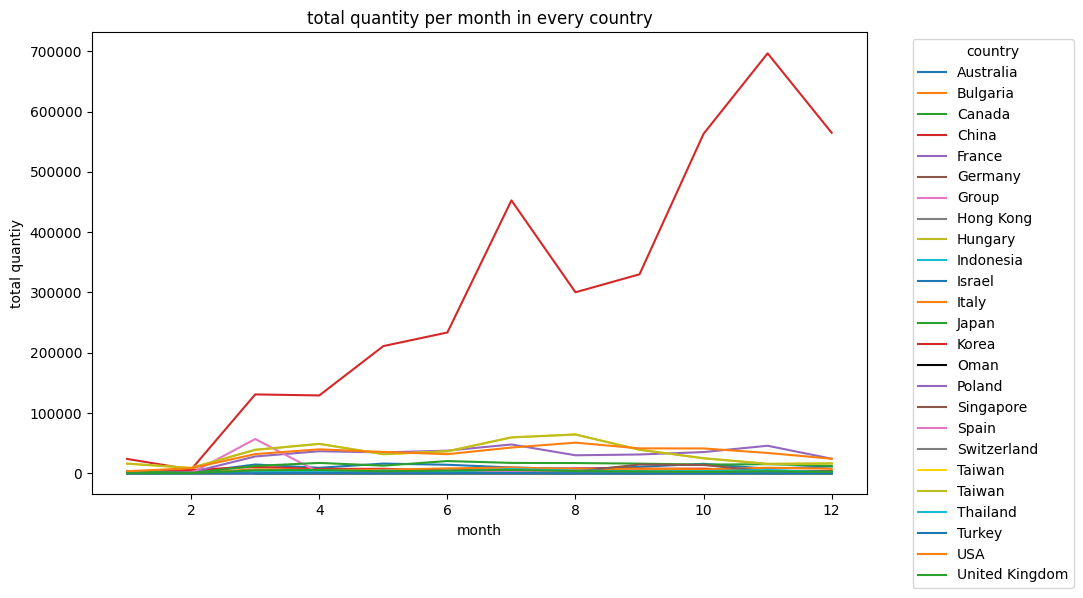

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售量
grouped_data = df.groupby(['country', df['time'].dt.month])['total_quantity'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 繪製圖表
fig, ax = plt.subplots(figsize=(10, 6))

# 遍歷不同的國家
for country in grouped_data['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    if country == 'Taiwan':
        ax.plot(country_data['time'], country_data['total_quantity'], label=country, color='gold')
    if country == 'Oman':
        ax.plot(country_data['time'], country_data['total_quantity'], label=country, color='black')
    else:
        ax.plot(country_data['time'], country_data['total_quantity'], label=country)

ax.set_xlabel('month')
ax.set_ylabel('total quantiy')
ax.legend(title='country',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('total quantity per month in every country')
plt.show()


###Top 4 & Bottom 3

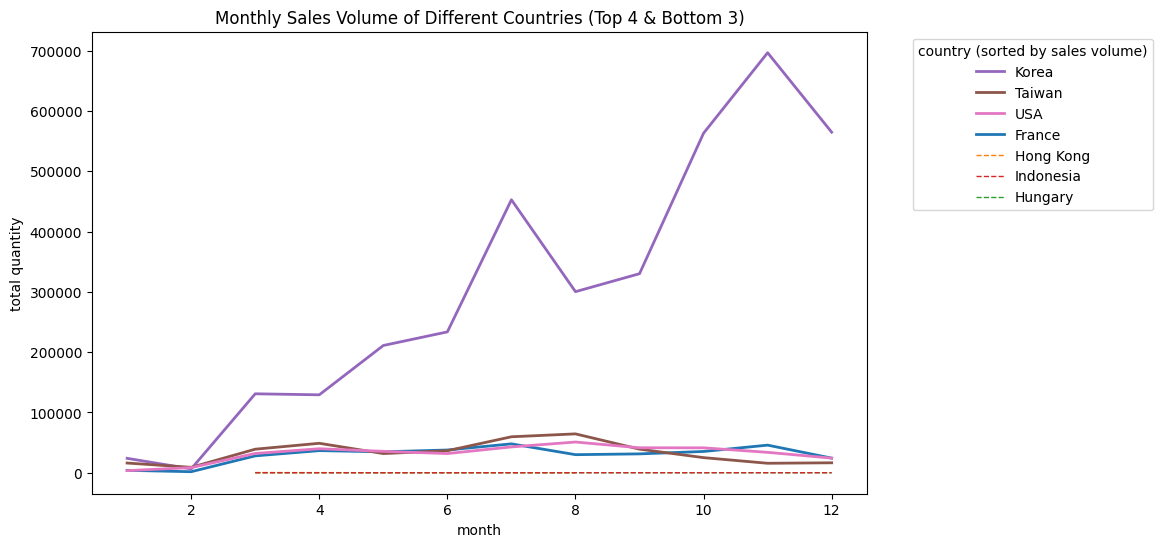

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售量
grouped_data = df.groupby(['country', df['time'].dt.month])['total_quantity'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 計算每個國家的總銷售量
total_sales_by_country = grouped_data.groupby('country')['total_quantity'].sum()

# 根據銷售量排序
sorted_countries = total_sales_by_country.sort_values(ascending=False).index

# 取得銷售量前三高和倒數三的國家
selected_countries = sorted_countries[:4].union(sorted_countries[-3:])

# 繪製圖表
fig, ax = plt.subplots(figsize=(10, 6))

# 遍歷選擇的國家
for country in selected_countries:
    country_data = grouped_data[grouped_data['country'] == country]
    linestyle = '-' if country in sorted_countries[:4] else '--'
    linewidth = 2 if country in sorted_countries[:4] else 1
    ax.plot(country_data['time'], country_data['total_quantity'], label=country, linestyle=linestyle, linewidth=linewidth)

# 重新排序圖例
handles, labels = ax.get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: total_sales_by_country[x[1]], reverse=True)
sorted_handles, sorted_labels = zip(*sorted_handles_labels)
ax.legend(sorted_handles, sorted_labels, title='country (sorted by sales volume)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('month')
ax.set_ylabel('total quantity')
plt.title('Monthly Sales Volume of Different Countries (Top 4 & Bottom 3)')
plt.show()


從圖中可以發現，韓國的美妝商品相較其他國家有壓倒性的銷售量，且有逐月攀升的趨勢，並於年末達到高峰，年初推測可能因為農曆新年的影響，商家物流皆停擺，因此是銷售量的低谷。而位居第二、三、四名的台灣、美國以及法國的美妝商品總體來看皆無特別的銷售趨勢。而銷售額表現最差的三個國家由虛線表示，分別為香港、印尼以及匈牙利。

###Bottom 3

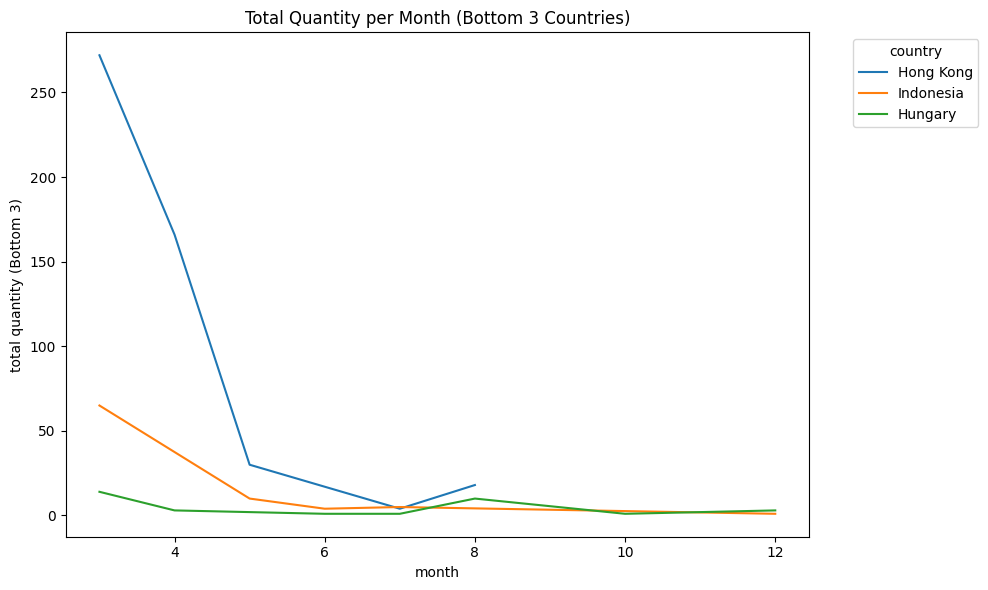

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售量
grouped_data = df.groupby(['country', df['time'].dt.month])['total_quantity'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 計算每個國家的總銷售量
total_sales_by_country = grouped_data.groupby('country')['total_quantity'].sum()

# 根據銷售量排序
sorted_countries = total_sales_by_country.sort_values(ascending=False).index

# 取得銷售量倒數三的國家
bottom_countries = sorted_countries[-3:]

# 繪製子圖
fig, ax = plt.subplots(figsize=(10, 6))

# 繪製銷售量倒數三的國家
for country in bottom_countries:
    country_data = grouped_data[grouped_data['country'] == country]
    ax.plot(country_data['time'], country_data['total_quantity'], label=country)

# 設定x軸標籤
ax.set_xlabel('month')

# 添加圖例
ax.legend(title='country', bbox_to_anchor=(1.05, 1), loc='upper left')

# 設定y軸標籤
ax.set_ylabel('total quantity (Bottom 3)')

# 設定標題
ax.set_title('Total Quantity per Month (Bottom 3 Countries)')

plt.tight_layout()
plt.show()


bottom 3的三個國家並不存在銷售趨勢，不具備發展潛力

###中文字型

In [ ]:
import matplotlib as mpl
import matplotlib.font_manager as fm

In [ ]:
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

--2024-01-09 19:25:48--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.174.113, 173.194.174.100, 173.194.174.101, ...
Connecting to drive.google.com (drive.google.com)|173.194.174.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/fesl0uhcf7uvngqpu1133b41g72v23m4/1704828300000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=53041dc5-7f83-4d54-b35f-67fee7ed6f72 [following]
--2024-01-09 19:25:52--  https://doc-0k-9o-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/fesl0uhcf7uvngqpu1133b41g72v23m4/1704828300000/02847987870453524430/*/1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_?uuid=53041dc5-7f83-4d54-b35f-67fee7ed6f72
Resolving doc-0k-9o-docs.googleusercontent.com (doc-0k-9o-docs.googleusercontent.com)... 142.251.8.132, 2404:6800:4008:c15::84
Connecting to doc

In [ ]:
fm.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')

In [ ]:
[f.name for f in fm.fontManager.ttflist]

['DejaVu Serif Display',
 'STIXNonUnicode',
 'STIXSizeThreeSym',
 'STIXGeneral',
 'STIXSizeOneSym',
 'STIXNonUnicode',
 'STIXNonUnicode',
 'DejaVu Sans',
 'DejaVu Sans',
 'STIXNonUnicode',
 'DejaVu Sans',
 'DejaVu Serif',
 'STIXSizeFourSym',
 'DejaVu Sans Mono',
 'cmb10',
 'DejaVu Serif',
 'STIXGeneral',
 'DejaVu Sans',
 'STIXSizeFourSym',
 'cmmi10',
 'DejaVu Sans Mono',
 'cmex10',
 'cmr10',
 'cmsy10',
 'DejaVu Sans Mono',
 'STIXSizeTwoSym',
 'cmtt10',
 'DejaVu Serif',
 'STIXSizeFiveSym',
 'STIXGeneral',
 'STIXSizeOneSym',
 'STIXSizeThreeSym',
 'DejaVu Sans Display',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'STIXGeneral',
 'cmss10',
 'STIXSizeTwoSym',
 'Humor Sans',
 'Liberation Mono',
 'Liberation Sans Narrow',
 'Liberation Sans',
 'Liberation Mono',
 'Liberation Serif',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Liberation Sans Narrow',
 'Liberation Mono',
 'Liberation Sans',
 'Liberation Serif',
 'Liberation Sans',
 'Liberation Mono',
 'Liberation Sans Narrow',
 'Liberation Ser

###細看銷售量前四名之國家前五名的品牌（韓、台、美、法）

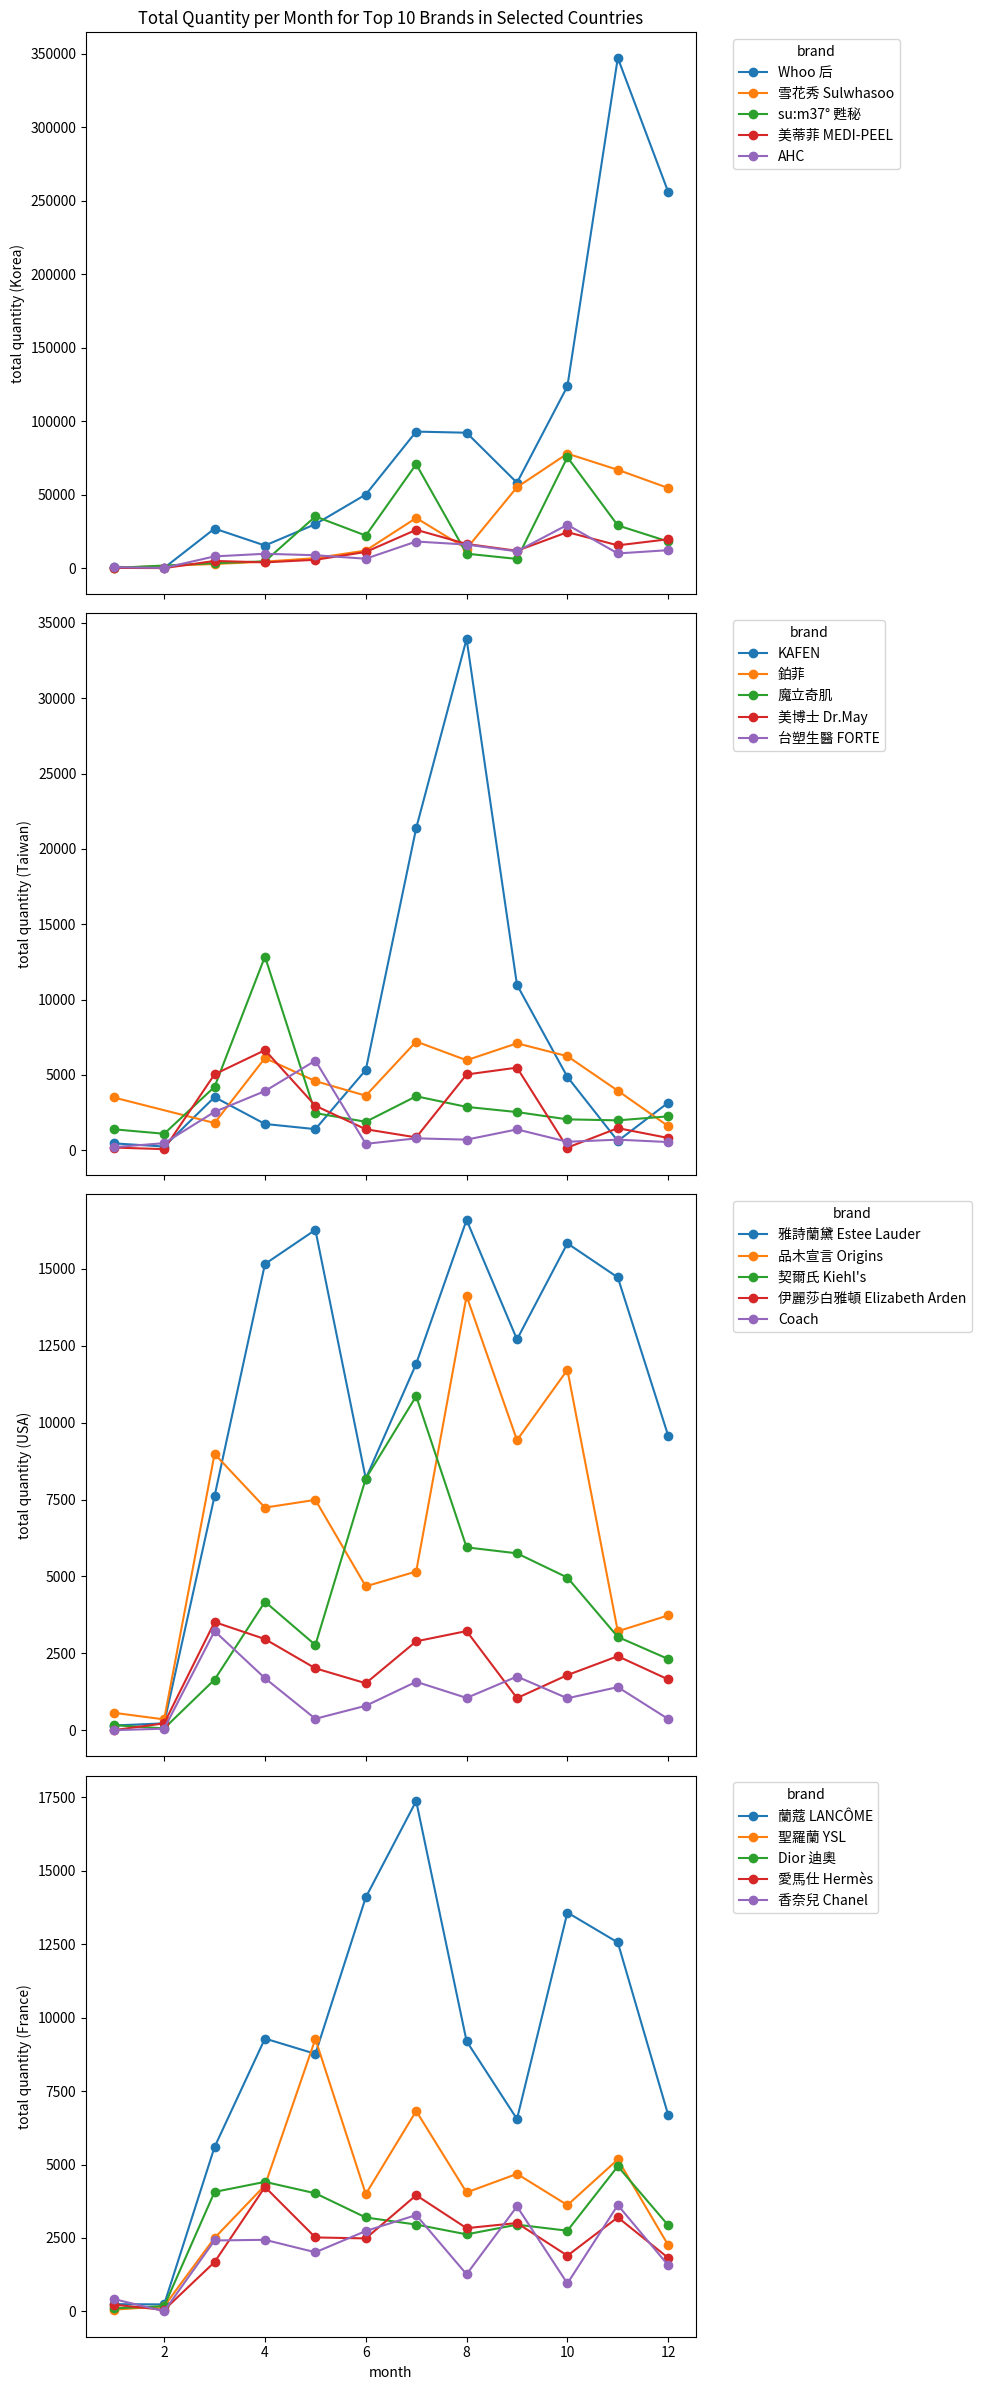

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按品牌、國家和月份進行分組，計算總銷售量
grouped_data_brand_country = df.groupby(['brand', 'country', df['time'].dt.month])['total_quantity'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data_brand_country['time'] = grouped_data_brand_country['time'].astype(int)

# 選擇特定國家
selected_countries = ['Korea', 'Taiwan', 'USA', 'France']

# 繪製圖表
fig, axes = plt.subplots(len(selected_countries), 1, figsize=(10, 6 * len(selected_countries)), sharex=True)

for i, country in enumerate(selected_countries):
    # 選擇特定國家的資料
    country_data = grouped_data_brand_country[grouped_data_brand_country['country'] == country]

    # 找出每個國家的銷售量前5名品牌
    top_brands = country_data.groupby('brand')['total_quantity'].sum().nlargest(5).index

    # 遍歷選擇的品牌
    for brand in top_brands:
        brand_data = country_data[country_data['brand'] == brand]
        axes[i].plot(brand_data['time'], brand_data['total_quantity'], label=f"{brand}", marker='o')

    # 添加圖例
    axes[i].legend(title='brand', bbox_to_anchor=(1.05, 1), loc='upper left')

    # 設定y軸標籤
    axes[i].set_ylabel(f'total quantity ({country})')

# 設定x軸標籤
axes[-1].set_xlabel('month')

# 設定標題
axes[0].set_title('Total Quantity per Month for Top 10 Brands in Selected Countries')

plt.tight_layout()
plt.show()


從品牌的角度細看銷售量前四名之國家，可以發現韓國和台灣皆有特定品牌在特定月份表現突出，韓國是年末的Whoo后，而台灣則是夏季的KAFEN以及四月的魔立奇肌

###細看Whoo 后於11月的暢銷前十名商品

In [ ]:
# 選取符合條件的行
selected_rows = df.loc[(df['brand'] == 'Whoo 后') & (df['time'].dt.month == 11), 'name']

# 打印商品名稱
selected_rows#715筆
selected_rows.nunique()#526筆

80979                           津率享洗卸組
81019                美妝保養品 2代重生密帖精華8ML
81040             CH2密帖復活保濕套組禮盒今天超級破盤價
81046                        拱辰享氣津活膚禮盒
81048                     拱辰享雪白煥膚凝膠1ML
                     ...              
92334                   BA拱辰享絲絨妝前露40ML
92369    138美現貨377O 拱辰享:雪 亮白防曬BB霜 40ML
92455                   113美 美白洗面乳40ML
92527     MCHỐNG NẮNG  TRẮNG. 2 TIP
92531                         M TRẮNG
Name: name, Length: 715, dtype: object


526

In [ ]:
# 找到重複的行
duplicates = selected_rows[selected_rows.duplicated(keep=False)]

# 計算每個商品名稱的出現次數
counts = duplicates.value_counts()

# 選取前十名
top_three_duplicates = counts.head(10)

# 打印結果
print(top_three_duplicates)

天氣丹華炫 蕾絲氣墊粉餅套裝                 33
 津率享洗面乳                        20
 還幼童眼膏套盒8件組                    15
 拱辰享水妍平衡水乳液面霜6件禮盒套組            11
 拱辰享美 平紋潤唇膏3G                  10
 拱辰享雪 泡沫洗面乳                    10
拱辰享雪玉凝系列6件禮盒套組                  9
 拱辰享美 平紋潤唇膏3G+ 拱辰享美 平紋潤唇膏3G     8
 天氣丹華炫美肌7件禮盒組                   7
 秘帖5件禮盒組                        7
Name: name, dtype: int64


在11月的暢銷前十名可看出拱辰系列商品深受民眾喜愛，並且以禮盒組、套裝的購買方式居多

##銷售額

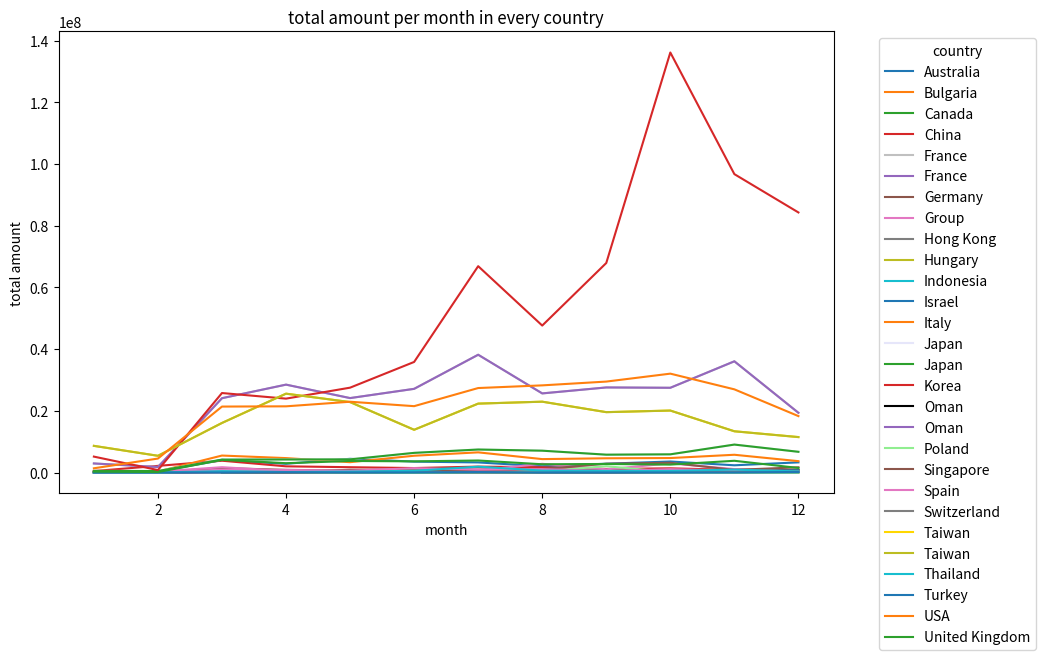

In [ ]:
# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售量
grouped_data = df.groupby(['country', df['time'].dt.month])['total_amount'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 繪製圖表
fig, ax = plt.subplots(figsize=(10, 6))

# 遍歷不同的國家
for country in grouped_data['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    if country == 'Taiwan':
        ax.plot(country_data['time'], country_data['total_amount'], label=country, color='gold')
    if country == 'Oman':
        ax.plot(country_data['time'], country_data['total_amount'], label=country, color='black')
    if country == 'France':
        ax.plot(country_data['time'], country_data['total_amount'], label=country, color='silver')
    if country == 'Japan':
        ax.plot(country_data['time'], country_data['total_amount'], label=country, color='lavender')
    if country == 'Poland':
        ax.plot(country_data['time'], country_data['total_amount'], label=country, color='lightgreen')
    else:
        ax.plot(country_data['time'], country_data['total_amount'], label=country)

ax.set_xlabel('month')
ax.set_ylabel('total amount')
ax.legend(title='country',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('total amount per month in every country')
plt.show()


###Top 4 & Bottom 3

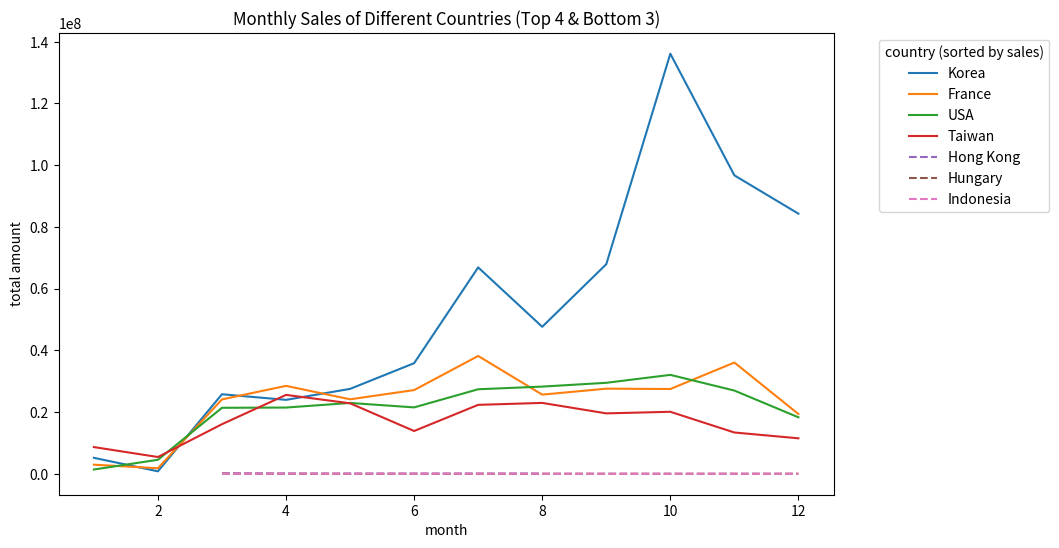

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售額
grouped_data = df.groupby(['country', df['time'].dt.month])['total_amount'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 計算每個國家的總銷售額
total_sales_by_country = grouped_data.groupby('country')['total_amount'].sum()

# 根據銷售額排序
sorted_countries = total_sales_by_country.sort_values(ascending=False).index

# 取得銷售額前三高和倒數三的國家
top_countries = sorted_countries[:4]
bottom_countries = sorted_countries[-3:]

# 繪製圖表
fig, ax = plt.subplots(figsize=(10, 6))

# 遍歷選擇的國家
for country in top_countries:
    country_data = grouped_data[grouped_data['country'] == country]
    ax.plot(country_data['time'], country_data['total_amount'], label=country)

# 遍歷選擇的國家
for country in bottom_countries:
    country_data = grouped_data[grouped_data['country'] == country]
    ax.plot(country_data['time'], country_data['total_amount'], label=country, linestyle='--')

# 重新排序圖例
handles, labels = ax.get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: total_sales_by_country[x[1]], reverse=True)
sorted_handles, sorted_labels = zip(*sorted_handles_labels)
ax.legend(sorted_handles, sorted_labels, title='country (sorted by sales)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('month')
ax.set_ylabel('total amount')
plt.title('Monthly Sales of Different Countries (Top 4 & Bottom 3)')
plt.show()


在銷售額拔得頭籌的同樣是韓國，而從法國和台灣於銷售量和銷售額的排名發生變動可以判斷，法國美妝商品的單價較高，相對的台灣美妝商品單價則較低。而香港、印尼、匈牙利三國的商品仍然為表現最差的三國，且於前述bottom 3的銷售量圖表可發現三個國家的產品並不具備銷售趨勢。

###細看銷售額前四名之國家前五名的品牌（韓、法、美、台）

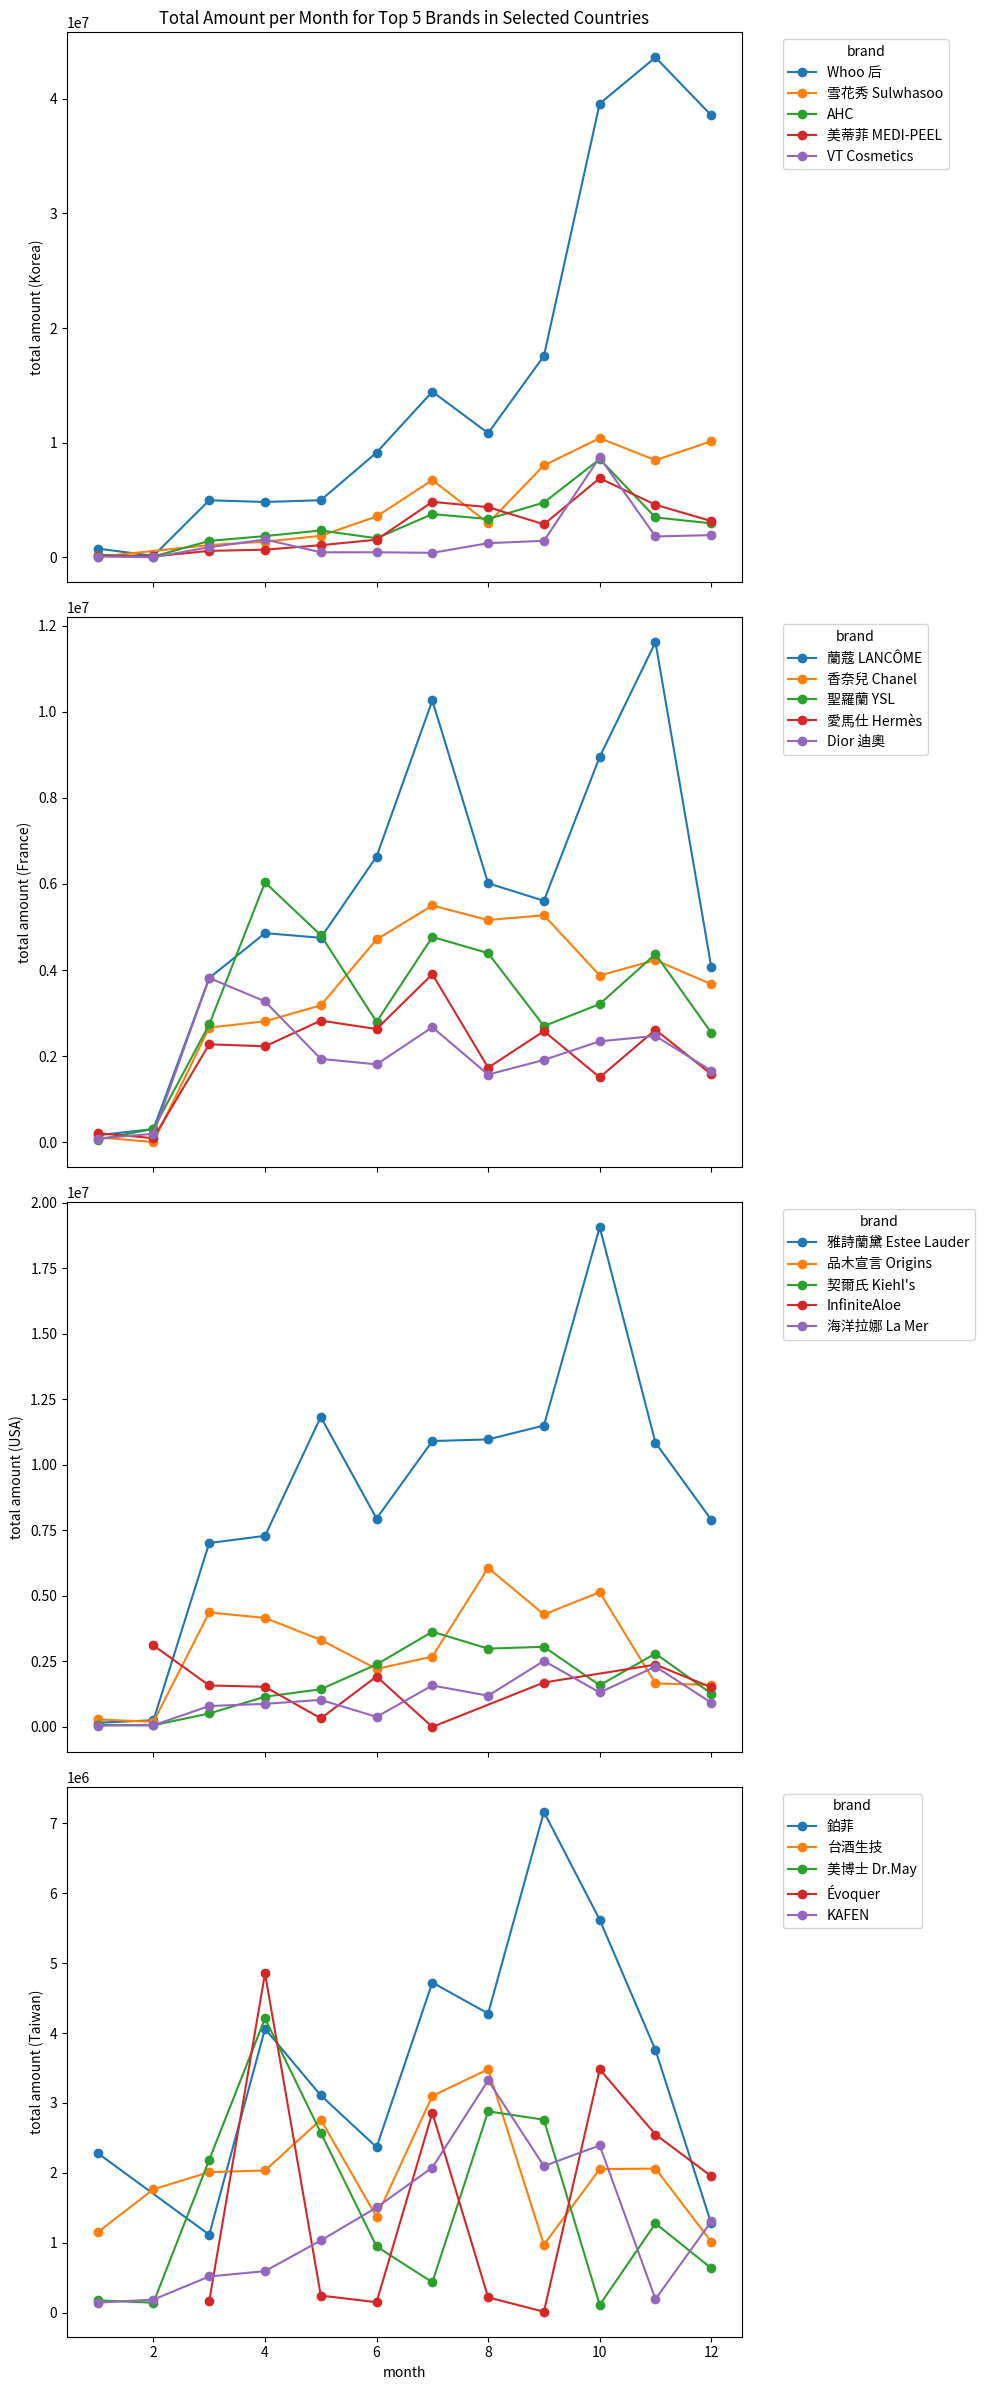

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按品牌、國家和月份進行分組，計算總銷售量
grouped_data_brand_country = df.groupby(['brand', 'country', df['time'].dt.month])['total_amount'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data_brand_country['time'] = grouped_data_brand_country['time'].astype(int)

# 選擇特定國家
selected_countries = ['Korea', 'France', 'USA', 'Taiwan']

# 繪製圖表
fig, axes = plt.subplots(len(selected_countries), 1, figsize=(10, 6 * len(selected_countries)), sharex=True)

for i, country in enumerate(selected_countries):
    # 選擇特定國家的資料
    country_data = grouped_data_brand_country[grouped_data_brand_country['country'] == country]

    # 找出每個國家的銷售量前5名品牌
    top_brands = country_data.groupby('brand')['total_amount'].sum().nlargest(5).index

    # 遍歷選擇的品牌
    for brand in top_brands:
        brand_data = country_data[country_data['brand'] == brand]
        axes[i].plot(brand_data['time'], brand_data['total_amount'], label=f"{brand}", marker='o')

    # 添加圖例
    axes[i].legend(title='brand', bbox_to_anchor=(1.05, 1), loc='upper left')

    # 設定y軸標籤
    axes[i].set_ylabel(f'total amount ({country})')

# 設定x軸標籤
axes[-1].set_xlabel('month')

# 設定標題
axes[0].set_title('Total Amount per Month for Top 5 Brands in Selected Countries')

plt.tight_layout()
plt.show()


##單筆消費圖

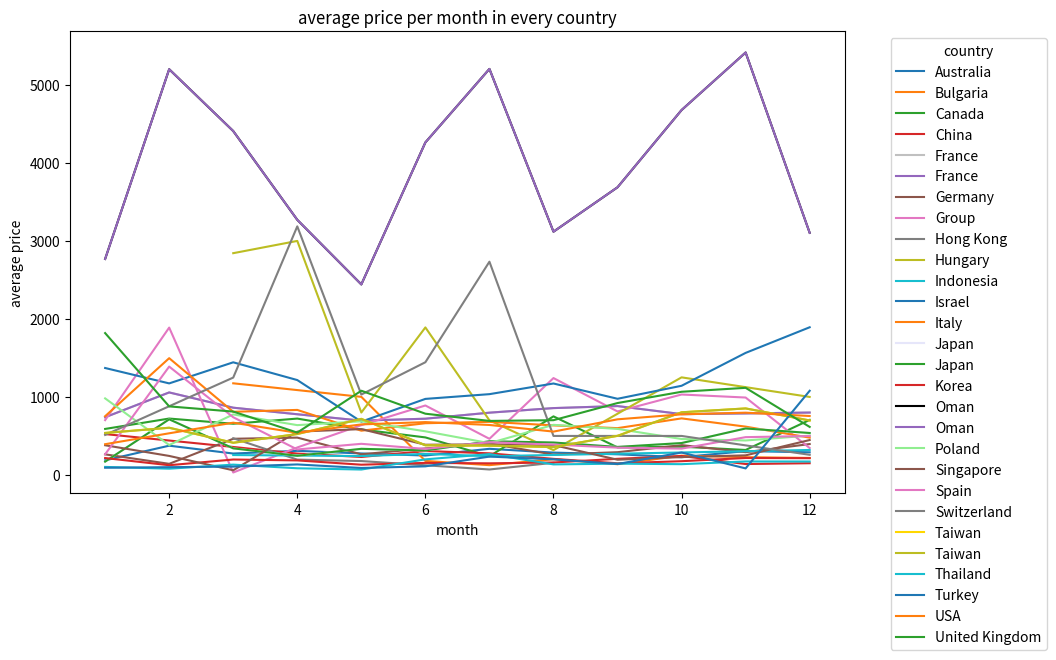

In [ ]:
# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按國家和月份進行分組，計算總銷售量和總銷售金額
grouped_data = df.groupby(['country', df['time'].dt.month]).agg(total_quantity=('total_quantity', 'sum'), total_amount=('total_amount', 'sum')).reset_index()

# 計算平均銷售單價
grouped_data['average_price'] = grouped_data['total_amount'] / grouped_data['total_quantity']

# 將字串形式的月份轉換為整數
grouped_data['time'] = grouped_data['time'].astype(int)

# 繪製圖表
fig, ax = plt.subplots(figsize=(10, 6))

# 遍歷不同的國家
for country in grouped_data['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    if country == 'Taiwan':
        ax.plot(country_data['time'], country_data['average_price'], label=country, color='gold')
    if country == 'Oman':
        ax.plot(country_data['time'], country_data['average_price'], label=country, color='black')
    if country == 'France':
        ax.plot(country_data['time'], country_data['average_price'], label=country, color='silver')
    if country == 'Japan':
        ax.plot(country_data['time'], country_data['average_price'], label=country, color='lavender')
    if country == 'Poland':
        ax.plot(country_data['time'], country_data['average_price'], label=country, color='lightgreen')
    else:
        ax.plot(country_data['time'], country_data['average_price'], label=country)

ax.set_xlabel('month')
ax.set_ylabel('average price')
ax.legend(title='country',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('average price per month in every country')
plt.show()


法國商品的單價很高!可推測這也是造成法國銷售額位居第一的原因
第二名意外的是匈牙利 因為單價高銷售量少所以無法在銷售額圖中脫穎而出
從圖表看來法國和匈牙利商品單價呈現週期性變動
在七月和十一月(法國商品單筆交易額高點)時 銷售量也有些微起伏故導致銷售額飆高
對於高單價商品建議已提高銷售量來取得更大的收益


#以品牌分析

<ipython-input-23-53aea9c9bf1a>:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  grouped_data_brand = df.groupby(['brand', 'country', df['time'].dt.month])['total_quantity', 'total_amount'].sum().reset_index()
<ipython-input-23-53aea9c9bf1a>:16: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  total_sales_by_brand = grouped_data_brand.groupby(['brand', 'country'])['total_quantity', 'total_amount'].sum()


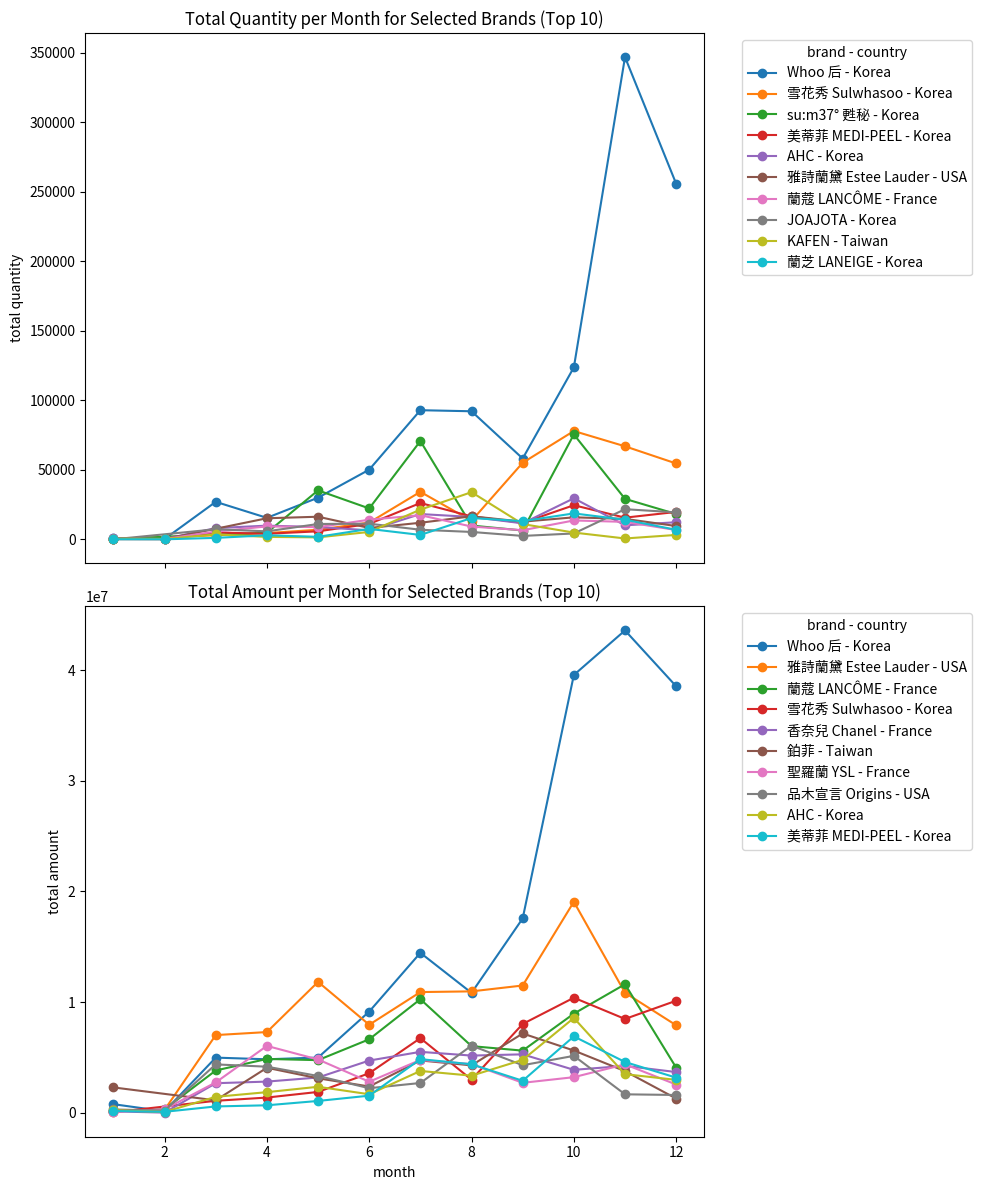

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）

# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 先按品牌和月份進行分組，計算總銷售量和總銷售額
grouped_data_brand = df.groupby(['brand', 'country', df['time'].dt.month])['total_quantity', 'total_amount'].sum().reset_index()

# 將字串形式的月份轉換為整數
grouped_data_brand['time'] = grouped_data_brand['time'].astype(int)

# 計算每個品牌的總銷售量和總銷售額
total_sales_by_brand = grouped_data_brand.groupby(['brand', 'country'])['total_quantity', 'total_amount'].sum()

# 根據銷售量排序
sorted_brands_quantity = total_sales_by_brand['total_quantity'].sort_values(ascending=False).index
sorted_brands_amount = total_sales_by_brand['total_amount'].sort_values(ascending=False).index

# 取得銷售量前十名的品牌
top_brands_quantity = sorted_brands_quantity[:10]
top_brands_amount = sorted_brands_amount[:10]

# 繪製圖表
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# 遍歷選擇的品牌
for brand, country in top_brands_quantity:
    brand_data = grouped_data_brand[(grouped_data_brand['brand'] == brand) & (grouped_data_brand['country'] == country)]
    axes[0].plot(brand_data['time'], brand_data['total_quantity'], label=f"{brand} - {country}", marker='o')

# 遍歷選擇的品牌
for brand, country in top_brands_amount:
    brand_data = grouped_data_brand[(grouped_data_brand['brand'] == brand) & (grouped_data_brand['country'] == country)]
    axes[1].plot(brand_data['time'], brand_data['total_amount'], label=f"{brand} - {country}", marker='o')

# 添加圖例，按照順序排序
legend_labels_quantity = [f"{brand} - {country}" for brand, country in top_brands_quantity]
legend_labels_amount = [f"{brand} - {country}" for brand, country in top_brands_amount]

axes[0].legend(title='brand - country', labels=legend_labels_quantity, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].legend(title='brand - country', labels=legend_labels_amount, bbox_to_anchor=(1.05, 1), loc='upper left')

# 設定x軸標籤
axes[1].set_xlabel('month')

# 設定y軸標籤
axes[0].set_ylabel('total quantity')
axes[1].set_ylabel('total amount')

# 設定標題
axes[0].set_title('Total Quantity per Month for Selected Brands (Top 10)')
axes[1].set_title('Total Amount per Month for Selected Brands (Top 10)')

plt.tight_layout()
plt.show()


##爆牌預測（不考慮季節性）
使用了兩個模型來比較預測結果，可以發現「Whoo 后」和「雅詩蘭黛」都位居前三，預期在2023年1月都會有較突出的銷售表現

###ARIMA模型

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

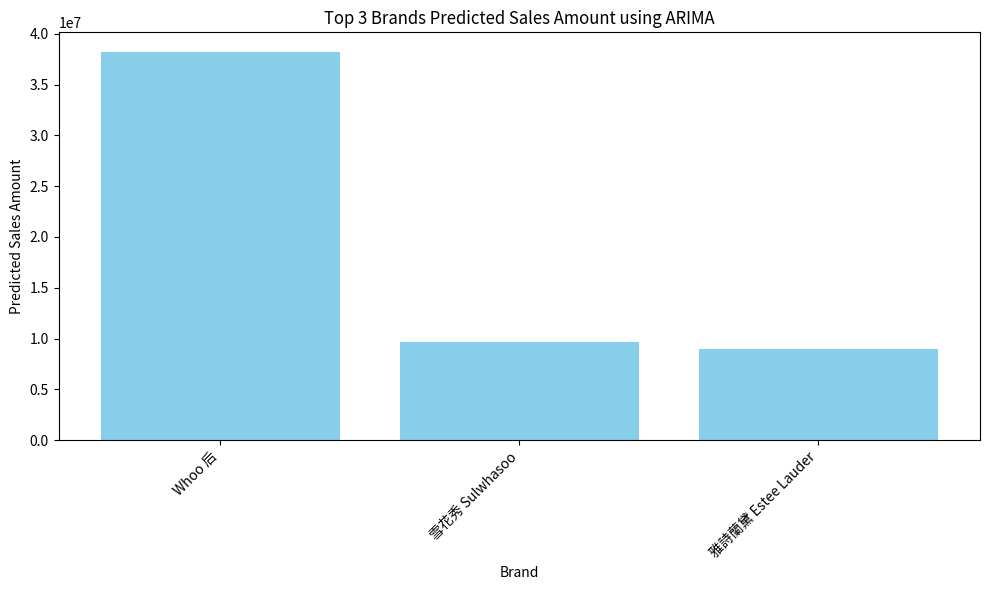

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）
# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 整合各月份各品牌的銷售額
grouped_data_brand = df.groupby(['brand', df['time'].dt.to_period('M')])['total_amount'].sum().reset_index()

# 找出 2022 年銷售額前 10 的品牌
top_10_brands_2022 = (
    grouped_data_brand[grouped_data_brand['time'].dt.year == 2022]
    .groupby('brand')['total_amount']
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

# 建立一個空的 DataFrame 來存放預測結果
predictions = pd.DataFrame(columns=['brand', 'predicted_value'])

# 遍歷前 10 的品牌
for brand in top_10_brands_2022:
    brand_data = grouped_data_brand[grouped_data_brand['brand'] == brand]

    # 使用 ARIMA 模型
    model = ARIMA(brand_data['total_amount'], order=(1, 1, 1))  # 適當設定 ARIMA 參數
    results = model.fit()

    # 進行未來 1 個月的預測
    predicted_value = results.get_forecast(steps=1).predicted_mean.iloc[0]

    # 將預測結果存入 DataFrame
    predictions = predictions.append({'brand': brand, 'predicted_value': predicted_value}, ignore_index=True)

# 排序預測結果
predictions = predictions.sort_values(by='predicted_value', ascending=False)

# 選出預測結果前三名的品牌
top_3_predictions = predictions.sort_values(by='predicted_value', ascending=False).head(3)

# 繪製長條圖
plt.figure(figsize=(10, 6))
plt.bar(top_3_predictions['brand'], top_3_predictions['predicted_value'], color='skyblue')
plt.xlabel('Brand')
plt.ylabel('Predicted Sales Amount')
plt.title('Top 3 Brands Predicted Sales Amount using ARIMA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


###Exponential Smoothing 模型

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-12-a6f9ac3a16c0>:37: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a fu

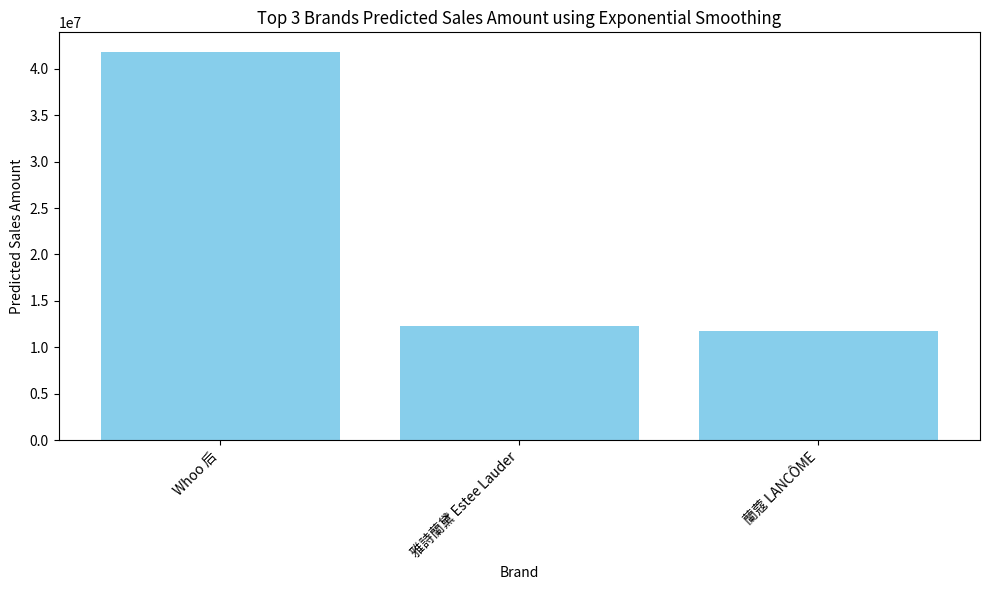

In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# 假設 df 為你的資料框（DataFrame）
# 將日期欄位轉換為 datetime 型別
df['time'] = pd.to_datetime(df['time'])

# 整合各月份各品牌的銷售額
grouped_data_brand = df.groupby(['brand', df['time'].dt.to_period('M')])['total_amount'].sum().reset_index()

# 找出 2022 年銷售額前 10 的品牌
top_10_brands_2022 = (
    grouped_data_brand[grouped_data_brand['time'].dt.year == 2022]
    .groupby('brand')['total_amount']
    .sum()
    .nlargest(10)
    .index
    .tolist()
)

# 建立一個空的 DataFrame 來存放預測結果
predictions = pd.DataFrame(columns=['brand', 'predicted_value'])

# 遍歷前 10 的品牌
for brand in top_10_brands_2022:
    brand_data = grouped_data_brand[grouped_data_brand['brand'] == brand]

    # 使用 Exponential Smoothing 模型
    model = ExponentialSmoothing(brand_data['total_amount'], trend='add', seasonal=None)
    results = model.fit()

    # 進行未來 1 個月的預測
    predicted_value = results.forecast(steps=1).iloc[0]

    # 將預測結果存入 DataFrame
    predictions = predictions.append({'brand': brand, 'predicted_value': predicted_value}, ignore_index=True)

# 選出預測結果前三名的品牌
top_3_predictions = predictions.sort_values(by='predicted_value', ascending=False).head(3)

# 繪製長條圖
plt.figure(figsize=(10, 6))
plt.bar(top_3_predictions['brand'], top_3_predictions['predicted_value'], color='skyblue')
plt.xlabel('Brand')
plt.ylabel('Predicted Sales Amount')
plt.title('Top 3 Brands Predicted Sales Amount using Exponential Smoothing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
top_10_brands_2022

['Whoo 后',
 '雅詩蘭黛 Estee Lauder',
 '蘭蔻 LANCÔME',
 '雪花秀 Sulwhasoo',
 '香奈兒 Chanel',
 '鉑菲',
 '聖羅蘭 YSL',
 '品木宣言 Origins',
 'AHC',
 '美蒂菲 MEDI-PEEL']